# Creación de un modelo TiDE con Darts

Como hemos visto en notebooks anteriores, un modelo muy útil cuando tratamos con varios gigas de datos es el TiDE. Anteriormente lo entrenamos con pytorch-forecasting, pero a la hora de llevarlo a producción es una libreria muy tediosa. Como respuesta Darts ofrece clases más amigables y sencillas de entender, a cambio de un tuning más simple y menos ajustable.

Toda la información del modelo ha sido extraida de la web oficial de Darts https://unit8co.github.io/darts/generated_api/darts.models.forecasting.tide_model.html#module-darts.models.forecasting.tide_model

Descarguemos los datos y hagamos las transformaciones necesarias

In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient


from pyspark.ml.feature import StringIndexer, OneHotEncoder,VectorAssembler, StandardScaler, SQLTransformer, Imputer
from pyspark.sql.types import FloatType
from pyspark.sql import functions as F

from pyspark.ml.functions import vector_to_array
from pyspark.sql.window import Window
import math
from torch.utils.data import IterableDataset, DataLoader
import pyarrow.parquet as pq

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TiDEModel
from darts.dataprocessing.transformers import MissingValuesFiller
from darts.utils.likelihood_models import QuantileRegression
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.preprocessing import RobustScaler


from clearml import Task
from tqdm.auto import tqdm
import joblib
import pandas as pd
from darts import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder as SklearnOneHotEncoder,StandardScaler as SklearnStandardScaler
from sklearn.cluster import KMeans


from setup import setenv
setenv()


The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [19]:

spark = MinioSparkClient(
    endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
    access_key=os.getenv("MINIO_ACCESS_KEY"),
    secret_key=os.getenv("MINIO_SECRET_KEY"),
    bucket_name="pd2",
    base_dir="cityenjoyer",
    memory = 16,
    heapsize = 8,
    num_part = 2000,
    verbose=True
)
spark.connect()

26/04/09 17:40:51 WARN Utils: Your hostname, danpanto-OMEN-Gaming-Laptop-16-ap0xxx resolves to a loopback address: 127.0.1.1; using 192.168.7.79 instead (on interface eno1)
26/04/09 17:40:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://mmlspark.azureedge.net/maven added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/danpanto/.ivy2/cache
The jars for the packages stored in: /home/danpanto/.ivy2/jars
com.microsoft.azure#synapseml_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7c738b3d-ec0c-4643-8c58-bd6bca195b35;1.0
	confs: [default]


:: loading settings :: url = jar:file:/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found com.microsoft.azure#synapseml_2.12;1.1.2 in central
	found com.microsoft.azure#synapseml-core_2.12;1.1.2 in central
	found org.apache.spark#spark-avro_2.12;3.5.0 in central
	found org.tukaani#xz;1.9 in central
	found commons-lang#commons-lang;2.6 in central
	found org.scalactic#scalactic_2.12;3.2.14 in central
	found org.scala-lang#scala-reflect;2.12.15 in central
	found io.spray#spray-json_2.12;1.3.5 in central
	found com.jcraft#jsch;0.1.54 in central
	found org.apache.httpcomponents.client5#httpclient5;5.1.3 in central
	found org.apache.httpcomponents.core5#httpcore5;5.1.3 in central
	found org.apache.httpcomponents.core5#httpcore5-h2;5.1.3 in central
	found org.slf4j#slf4j-api;1.7.25 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpmime;4.5.13 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found commons-logging#commons-logging;1.2 in central

KeyboardInterrupt: 

In [ ]:

df = spark.read_parquet("prepared_for_model/20260323_132105_agg.parquet")

df.show()

+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|avg_amount| Latitude| Longitude|hour|dow|            hour_sin|            hour_cos|            dow_sin|            dow_cos|
+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|       0|         263|2023-06-01 04:00:00|    14|     10730.5| 3877.7144|40.778767| -73.95101|   4|  5|  0.8660254037844386|  0.5000000000000001|-0.9749279121818236|-0.2225209339563146|
|       0|         262|2023-06-01 06:00:00|    59|    4567.576| 2454.5425|40.775932| -73.94651|   6|  5|                 1.0|6.123233995736766...|-0.9749279121818236|-0.2225209339563146|
|       0|         163|2023-06-01 09:00:00|   141|   4182.0566| 2

Para usar darts ya no necesitamos usar onehotencoders o los centroides, la propia libreria nos proporciona embeddings que van a aprender los mejores vectores para cada zona

In [ ]:
# Limpiamos nulos
df_clean = df.na.drop(subset=["demand", "PULocationID", "VendorID", "timestamp"])

# Creamos una columna que sea el ID único de la serie temporal
df_clean = df_clean.withColumn(
    "Series_ID", 
    F.concat_ws("_", F.col("VendorID"), F.col("PULocationID"))
)

# Ahora particionamos por esa nueva columna, 
# esto nos permite tener un folder por cada combinación y 
# nos permite usar darts con mini datasets que podemos pasar a pandas
df_clean.write \
    .partitionBy("Series_ID") \
    .mode("overwrite") \
    .parquet("../data/data_darts.parquet")

print("Datos exportados correctamente por Vendor y Zona.")

Datos exportados correctamente por Vendor y Zona.


Ahora creamos las listas preparadas para usar darts

In [ ]:
base_path = "../data/data_darts.parquet/"
# Buscamos las carpetas con la nueva clave (ej: Series_ID=0_262)
series_folders = [d for d in os.listdir(base_path) if d.startswith("Series_ID=")]

target_series_list = []
past_covariates_list = []
future_covariates_list = []

for folder in series_folders:
    # Extraemos el Vendor y la Zona del nombre de la carpeta (ej. "0_262")
    # folder es algo como "Series_ID=0_262"
    id_str = folder.split("=")[1] 
    vendor_id, zone_id = id_str.split("_")
    
    # Leemos el parquet de esta combinación específica
    df_serie = pd.read_parquet(Path(base_path, folder))
    df_serie = df_serie.sort_values("timestamp")

    static_covs = pd.DataFrame({
        "VendorID": [float(vendor_id)],
        "PULocationID": [float(zone_id)]
    })
    
    ts_target = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols="demand",
        static_covariates=static_covs,
        freq="h",                      
        fill_missing_dates=True,      
        fillna_value=0.0,              
    )
    target_series_list.append(ts_target)
    
    # 2. Pasadas (Distancia y Precio)
    ts_past = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["avg_distance", "avg_amount"],
        freq="h",
        fill_missing_dates=True,
        fillna_value=0.0             
    )
    past_covariates_list.append(ts_past)
    
    # 3. Futuras (Tiempo trigonométrico)
    ts_future_raw = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["hour_sin", "hour_cos", "dow_sin", "dow_cos"],
        freq="h",
        fill_missing_dates=True
    )
    
    # Interpolamos los NaN para que la curva trigonométrica siga siendo perfecta
    filler = MissingValuesFiller()
    ts_future = filler.transform(ts_future_raw)
    future_covariates_list.append(ts_future)

print(f"Listas creadas con {len(target_series_list)} series temporales únicas.")

Listas creadas con 1042 series temporales únicas.


Vamos a crear los conjuntos de entrenamiento

In [ ]:
MIN_LENGTH = 300  # Horas mínimas necesarias para que la red neuronal pueda aprender algo
corte_temporal = 0.80

#Vamos a seleccionar solo los datos a partir de 2023, que es el punto en el que se estabiliza la demanda
fecha_inicio = pd.Timestamp("2023-01-01")

train_target, val_target = [], []
train_past, val_past = [], []
train_future, val_future = [], []

series_descartadas = 0

for ts_t, ts_p, ts_f in zip(target_series_list, past_covariates_list, future_covariates_list):
    
    if ts_t.end_time() < fecha_inicio:
        series_descartadas += 1
        continue

    if ts_t.start_time() < fecha_inicio:
        ts_t2 = ts_t.drop_before(fecha_inicio)
        ts_p2 = ts_p.drop_before(fecha_inicio)
        ts_f2 = ts_f.drop_before(fecha_inicio)

    if len(ts_t2) < MIN_LENGTH:
        series_descartadas += 1
        continue

        
    # Calculamos la FECHA EXACTA del 80%
    punto_de_corte = ts_t2.get_timestamp_at_point(corte_temporal)
    
    # Cortamos las 3 series
    t_train, t_val = ts_t2.split_before(punto_de_corte)
    p_train, p_val = ts_p2.split_before(punto_de_corte)
    f_train, f_val = ts_f2.split_before(punto_de_corte)
    
    # Comprobación de seguridad 
    assert t_train.end_time() == p_train.end_time() == f_train.end_time(), "¡Error! Desalineación detectada."
    
    # Guardamos en las listas
    train_target.append(t_train)
    val_target.append(t_val)
    
    train_past.append(p_train)
    val_past.append(p_val)
    
    train_future.append(f_train)
    val_future.append(f_val)

print(f"¡Series divididas!")
print(f"Series válidas para entrenar: {len(train_target)}")
print(f"Series descartadas por ser muy cortas: {series_descartadas}")

¡Series divididas!
Series válidas para entrenar: 1037
Series descartadas por ser muy cortas: 5


hay zonas como se ve en el codigo que son descartadas por no tener precticamente historial, básicamente son outliers. Como el tide no puede predecir para estas zonas, simplemente relegaremos sus predicciones al otro modelo o a una baseline y ya

## ENTRENAMIENTO

In [ ]:
%load_ext tensorboard
%tensorboard --logdir mis_logs_tide

Reusing TensorBoard on port 6006 (pid 7503), started 2:47:00 ago. (Use '!kill 7503' to kill it.)

In [ ]:
from pytorch_lightning.callbacks import EarlyStopping 

#Tratamiento inicial de los datos
print("Escalando los datos...")

# Escalamos la demanda (Target)
scaler_target = Scaler()
train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)

# Escalamos la distancia y el precio (Past Covariates)
scaler_past = Scaler()
train_past_scaled = scaler_past.fit_transform(train_past)
val_past_scaled = scaler_past.transform(val_past)

#Creamos el objeto de Tide
print("Inicializando el cerebro TiDE...")

detenedor = EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.001,
    mode="min",
)

torch.set_float32_matmul_precision('high') #Esta instrucción activa los cores tensoriales 
modelo_tide = TiDEModel(
    input_chunk_length=72,   
    output_chunk_length=24,  
    num_encoder_layers=3,  
    num_decoder_layers=3,  
    decoder_output_dim=32,
    hidden_size=512,
    dropout=0.1,
    
    likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),

    batch_size=1024,          
    
    n_epochs=10,              
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    log_tensorboard=True,         
    
   
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 1.0,
        "callbacks": [detenedor] ,
        "precision": "32-true"  #quita esto si no se van a usar los cores tensoriales
    },

    work_dir="darts_models", 
    model_name="tide_nyc_v1",         
    save_checkpoints=True,            
    force_reset=True,                 

    
)

#Pasamos los datos escalado a float 32 para poder usar la configuración 16 mixed de la GPU
print("Convirtiendo datos a Float32 para la GPU...")

train_target_scaled = [ts.astype(np.float32) for ts in train_target_scaled]
train_past_scaled = [ts.astype(np.float32) for ts in train_past_scaled]
train_future = [ts.astype(np.float32) for ts in train_future]

val_target_scaled = [ts.astype(np.float32) for ts in val_target_scaled]
val_past_scaled = [ts.astype(np.float32) for ts in val_past_scaled]
val_future = [ts.astype(np.float32) for ts in val_future]

#Entrenamiento
print("¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)")

modelo_tide.fit(
    series=train_target_scaled,
    past_covariates=train_past_scaled,
    future_covariates=train_future,       
    val_series=val_target_scaled,
    val_past_covariates=val_past_scaled,
    val_future_covariates=val_future,
    dataloader_kwargs={"num_workers": 8},
    verbose=True  ,                        # Para ver la barra de progreso
)


print("¡Entrenamiento finalizado con éxito!")

Escalando los datos...
Inicializando el cerebro TiDE...
Convirtiendo datos a Float32 para la GPU...


number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ past_cov_projection   │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 6  │ future_cov_projection │ _ResidualBlock   │  4.6 K │ train │     0 │
│ 7  │ encoders              │ Sequential       │  2.6 M │ train │     0 │
│ 8  │ decoders              │ Sequential       │  4.2 M │ train │     0 │
│ 9  │ temporal_decoder      │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 10 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 6.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.8 M                                                                                                
Total estimated model params size (MB): 27                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

¡Entrenamiento finalizado con éxito!


Veamos como rinde el mejor modelo

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1037) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¡Encontrada! (Serie 147). Preparando la máquina del tiempo...
Calculando hora a hora (Ventana Deslizante)...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1037) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()`

¡100 horas completadas con éxito!
--> MAE Realista (Backtesting 100h): 11.53 taxis de error en promedio.


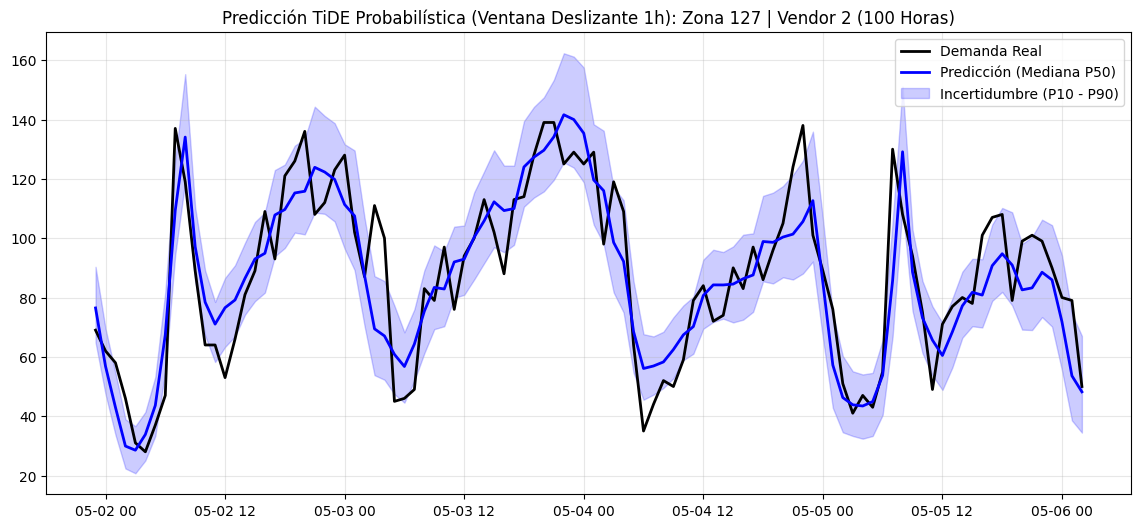

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Buscar la serie exacta
indice_buscado = -1
for i, ts in enumerate(val_target):
    vendor = ts.static_covariates["VendorID"].iloc[0]
    zona = ts.static_covariates["PULocationID"].iloc[0]
    
    if vendor == 2 and zona == 127:
        indice_buscado = i
        break

if indice_buscado == -1:
    print("¡Vaya! La Zona 127 con Vendor 2 no existe o fue descartada.")
else:
    print(f"¡Encontrada! (Serie {indice_buscado}). Preparando la máquina del tiempo...")
    
    # 2. Reconstruimos los ingredientes
    serie_pasado = train_target_scaled[indice_buscado]
    pasado_completo = train_past_scaled[indice_buscado].append(val_past_scaled[indice_buscado])
    futuro_completo = train_future[indice_buscado].append(val_future[indice_buscado])
    
    # Listas para guardar las 100 predicciones
    pred_p10_lista = []
    pred_p50_lista = []
    pred_p90_lista = []
    
    print("Calculando hora a hora (Ventana Deslizante)...")
    
    # 3. EL BUCLE MÁGICO (Predecir solo la siguiente hora, 100 veces)
    for hora in range(100):
        # Pedimos n=1 (¡100% legal para Darts!)
        pred_escalada = modelo_tide.predict(
            n=1,
            series=serie_pasado,
            past_covariates=pasado_completo,
            future_covariates=futuro_completo,
            predict_likelihood_parameters=True, 
            verbose=False # Silenciamos la barra de progreso para que no moleste 100 veces
        )
        
        # Desescalar ese único dato
        pred_real = scaler_target.inverse_transform(pred_escalada)
        df_pred = pred_real.to_dataframe()
        
        # Guardar las 3 líneas
        pred_p10_lista.append(df_pred.iloc[0, 0])
        pred_p50_lista.append(df_pred.iloc[0, 1])
        pred_p90_lista.append(df_pred.iloc[0, 2])
        
        # AVANZAR EN EL TIEMPO: Cogemos la hora real de validación que acaba de pasar
        # y se la pegamos a la serie para que el modelo la use en el siguiente paso
        hora_real = val_target_scaled[indice_buscado][hora : hora+1]
        serie_pasado = serie_pasado.append(hora_real)

    print("¡100 horas completadas con éxito!")
    
    # 4. EXTRAER LOS DATOS REALES (100h) Y CALCULAR EL MAE
    real_100h = val_target[indice_buscado][:100]
    df_real = real_100h.to_dataframe()
    fechas = df_real.index
    
    # MAE = Media de la diferencia absoluta entre la Realidad y la Mediana P50
    error_mae = np.mean(np.abs(df_real.iloc[:, 0].values - pred_p50_lista))
    print(f"--> MAE Realista (Backtesting 100h): {error_mae:.2f} taxis de error en promedio.")
    
    # 5. ¡A DIBUJAR LA OBRA MAESTRA!
    plt.figure(figsize=(14, 6))
    
    plt.plot(fechas, df_real.iloc[:, 0], label="Demanda Real", color="black", linewidth=2)
    plt.plot(fechas, pred_p50_lista, label="Predicción (Mediana P50)", color="blue", linewidth=2)
    
    # Sombreado de incertidumbre
    plt.fill_between(
        fechas,
        pred_p10_lista,
        pred_p90_lista,
        alpha=0.2, color="blue", label="Incertidumbre (P10 - P90)"
    )
    
    plt.title("Predicción TiDE Probabilística (Ventana Deslizante 1h): Zona 127 | Vendor 2 (100 Horas)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import numpy as np

modelo_tide = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_v1",          # El nombre que le dimos a la versión
    work_dir="darts_models", # La carpeta "padre" donde se guardó
    best=True  ,                       # ¡Darts buscará el mejor archivo .pth automáticamente!
    weights_only=False  
)
print("Empaquetando los datos de TODAS las zonas...")

# 1. Juntar el pasado y el futuro de todas las series de golpe (List Comprehension)
# Esto crea las listas completas para pasárselas a la GPU
pasados_completos = [t_p.append(v_p) for t_p, v_p in zip(train_past_scaled, val_past_scaled)]
futuros_completos = [t_f.append(v_f) for t_f, v_f in zip(train_future, val_future)]

print("Enviando miles de series a la GPU a la vez... ¡Agárrate!")

# 2. PREDICCIÓN MASIVA EN BATCH
# En lugar de pasar un índice, le pasamos las listas completas. 
# La GPU calculará las >1000 zonas simultáneamente.
preds_escaladas_lista = modelo_tide.predict(
    n=24,
    series=train_target_scaled,       
    past_covariates=pasados_completos, 
    future_covariates=futuros_completos,
    predict_likelihood_parameters=True,
    verbose=True
)

print("Desescalando los resultados a la realidad...")
# 3. Desescalado masivo (El Scaler también puede procesar listas enteras)
preds_reales_lista = scaler_target.inverse_transform(preds_escaladas_lista)

print("Calculando los errores zona por zona...")
# 4. Calcular el error (MAE) iterando sobre los resultados
maes_por_zona = []

for i in range(len(preds_reales_lista)):
    # Extraer la predicción P50 (Mediana)
    df_pred = preds_reales_lista[i].to_dataframe()
    pred_p50 = df_pred.iloc[:, 1].values 
    
    # Extraer la realidad de esa misma zona (las primeras 24h del val_target)
    real_24h = val_target[i][:24].to_dataframe().iloc[:, 0].values
    
    # Calcular el MAE matemático (solo añadimos el error si no hay datos corruptos)
    if len(pred_p50) == len(real_24h):
        error = np.mean(np.abs(real_24h - pred_p50))
        maes_por_zona.append(error)

# 5. RESULTADOS GLOBALES
mae_global = np.mean(maes_por_zona)
mediana_mae = np.median(maes_por_zona)

print("\n==================================================")
print("MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)")
print("==================================================")
print(f"MAE Promedio: {mae_global:.2f} taxis de error.")
print(f"Mediana MAE:  {mediana_mae:.2f} taxis de error.")
print("==================================================")

Empaquetando los datos de TODAS las zonas...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Enviando miles de series a la GPU a la vez... ¡Agárrate!


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generating TimeSeries:   0%|          | 0/1037 [00:00<?, ?it/s]

Desescalando los resultados a la realidad...
Calculando los errores zona por zona...

MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)
MAE Promedio: 4.63 taxis de error.
Mediana MAE:  2.41 taxis de error.


## Mejora del modelo, usar un RobustScaler. 

Como predecimos 24 horas simultáneamente no podemos usar rolling windows, pero usar un minmax como hace un scaler comun simplemente destruye el entrenamiento al sufrir por los outliers, viendo esto lo mejor es usar un robustScaler, que hace un minmax pero con los percentiles 25 y 75, lo que hace que pese a que la escala no sea 0-1, los datos no se vuelvan 0.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir mis_logs_tide

In [ ]:


#Tratamiento inicial de los datos
print("Escalando los datos...")


scaler_target = Scaler(RobustScaler(), global_fit=False)
scaler_past = Scaler(RobustScaler(), global_fit=False)

# Escalamos la demanda (Target)
train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)

# Escalamos la distancia y el precio (Past Covariates)
train_past_scaled = scaler_past.fit_transform(train_past)
val_past_scaled = scaler_past.transform(val_past)

#Creamos el objeto de Tide
print("Inicializando el cerebro TiDE...")

torch.set_float32_matmul_precision('high') #Esta instrucción activa los cores tensoriales 
modelo_tide = TiDEModel(
    input_chunk_length=72,   
    output_chunk_length=24,  
    num_encoder_layers=3,  
    num_decoder_layers=3,  
    decoder_output_dim=64,
    hidden_size=512,
    dropout=0.1,
    likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),

    batch_size=1024,          
    
    n_epochs=10,              
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    log_tensorboard=True,         
    
   
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 1.0,
        "precision": "32-true"  #quita esto si no se van a usar los cores tensoriales
    },

    work_dir="darts_models", 
    model_name="tide_nyc_v2",         
    save_checkpoints=True,            
    force_reset=True,                 

    
)

#Pasamos los datos escalado a float 32 para poder usar la configuración 16 mixed de la GPU
print("Convirtiendo datos a Float32 para la GPU...")

train_target_scaled = [ts.astype(np.float32) for ts in train_target_scaled]
train_past_scaled = [ts.astype(np.float32) for ts in train_past_scaled]
train_future = [ts.astype(np.float32) for ts in train_future]

val_target_scaled = [ts.astype(np.float32) for ts in val_target_scaled]
val_past_scaled = [ts.astype(np.float32) for ts in val_past_scaled]
val_future = [ts.astype(np.float32) for ts in val_future]

#Entrenamiento
print("¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)")

modelo_tide.fit(
    series=train_target_scaled,
    past_covariates=train_past_scaled,
    future_covariates=train_future,       
    val_series=val_target_scaled,
    val_past_covariates=val_past_scaled,
    val_future_covariates=val_future,
    dataloader_kwargs={"num_workers": 8},
    verbose=True                          # Para ver la barra de progreso
)

print("¡Entrenamiento finalizado con éxito!")

Escalando los datos...
Inicializando el cerebro TiDE...
Convirtiendo datos a Float32 para la GPU...


number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ past_cov_projection   │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 6  │ future_cov_projection │ _ResidualBlock   │  4.6 K │ train │     0 │
│ 7  │ encoders              │ Sequential       │  2.6 M │ train │     0 │
│ 8  │ decoders              │ Sequential       │  6.6 M │ train │     0 │
│ 9  │ temporal_decoder      │ _ResidualBlock   │  7.0 K │ train │     0 │
│ 10 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 9.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.2 M                                                                                                
Total estimated model params size (MB): 36                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


¡Entrenamiento finalizado con éxito!


Veamos como rinde el mejor modelo

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1037) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¡Encontrada! (Serie 147). Preparando la máquina del tiempo...
Calculando hora a hora (Ventana Deslizante)...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=1037) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()`

¡100 horas completadas con éxito!
--> MAE Realista (Backtesting 100h): 18.73 taxis de error en promedio.


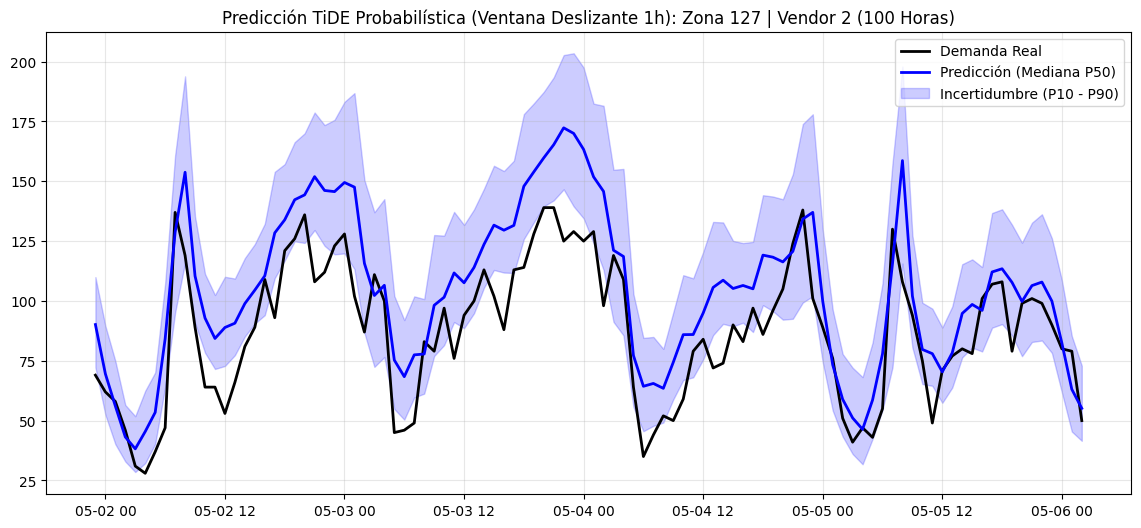

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Buscar la serie exacta
indice_buscado = -1
for i, ts in enumerate(val_target):
    vendor = ts.static_covariates["VendorID"].iloc[0]
    zona = ts.static_covariates["PULocationID"].iloc[0]
    
    if vendor == 2 and zona == 127:
        indice_buscado = i
        break

if indice_buscado == -1:
    print("¡Vaya! La Zona 127 con Vendor 2 no existe o fue descartada.")
else:
    print(f"¡Encontrada! (Serie {indice_buscado}). Preparando la máquina del tiempo...")
    
    # 2. Reconstruimos los ingredientes
    serie_pasado = train_target_scaled[indice_buscado]
    pasado_completo = train_past_scaled[indice_buscado].append(val_past_scaled[indice_buscado])
    futuro_completo = train_future[indice_buscado].append(val_future[indice_buscado])
    
    # Listas para guardar las 100 predicciones
    pred_p10_lista = []
    pred_p50_lista = []
    pred_p90_lista = []
    
    print("Calculando hora a hora (Ventana Deslizante)...")
    
    # 3. EL BUCLE MÁGICO (Predecir solo la siguiente hora, 100 veces)
    for hora in range(100):
        # Pedimos n=1 (¡100% legal para Darts!)
        pred_escalada = modelo_tide.predict(
            n=1,
            series=serie_pasado,
            past_covariates=pasado_completo,
            future_covariates=futuro_completo,
            predict_likelihood_parameters=True, 
            verbose=False # Silenciamos la barra de progreso para que no moleste 100 veces
        )
        
        # Desescalar ese único dato
        pred_real = scaler_target.inverse_transform(pred_escalada)
        df_pred = pred_real.to_dataframe()
        
        # Guardar las 3 líneas
        pred_p10_lista.append(df_pred.iloc[0, 0])
        pred_p50_lista.append(df_pred.iloc[0, 1])
        pred_p90_lista.append(df_pred.iloc[0, 2])
        
        # AVANZAR EN EL TIEMPO: Cogemos la hora real de validación que acaba de pasar
        # y se la pegamos a la serie para que el modelo la use en el siguiente paso
        hora_real = val_target_scaled[indice_buscado][hora : hora+1]
        serie_pasado = serie_pasado.append(hora_real)

    print("¡100 horas completadas con éxito!")
    
    # 4. EXTRAER LOS DATOS REALES (100h) Y CALCULAR EL MAE
    real_100h = val_target[indice_buscado][:100]
    df_real = real_100h.to_dataframe()
    fechas = df_real.index
    
    # MAE = Media de la diferencia absoluta entre la Realidad y la Mediana P50
    error_mae = np.mean(np.abs(df_real.iloc[:, 0].values - pred_p50_lista))
    print(f"--> MAE Realista (Backtesting 100h): {error_mae:.2f} taxis de error en promedio.")
    
    # 5. ¡A DIBUJAR LA OBRA MAESTRA!
    plt.figure(figsize=(14, 6))
    
    plt.plot(fechas, df_real.iloc[:, 0], label="Demanda Real", color="black", linewidth=2)
    plt.plot(fechas, pred_p50_lista, label="Predicción (Mediana P50)", color="blue", linewidth=2)
    
    # Sombreado de incertidumbre
    plt.fill_between(
        fechas,
        pred_p10_lista,
        pred_p90_lista,
        alpha=0.2, color="blue", label="Incertidumbre (P10 - P90)"
    )
    
    plt.title("Predicción TiDE Probabilística (Ventana Deslizante 1h): Zona 127 | Vendor 2 (100 Horas)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import numpy as np

print("Empaquetando los datos de TODAS las zonas...")

# 1. Juntar el pasado y el futuro de todas las series de golpe (List Comprehension)
# Esto crea las listas completas para pasárselas a la GPU
pasados_completos = [t_p.append(v_p) for t_p, v_p in zip(train_past_scaled, val_past_scaled)]
futuros_completos = [t_f.append(v_f) for t_f, v_f in zip(train_future, val_future)]

print("Enviando miles de series a la GPU a la vez... ¡Agárrate!")

# 2. PREDICCIÓN MASIVA EN BATCH
# En lugar de pasar un índice, le pasamos las listas completas. 
# La GPU calculará las >1000 zonas simultáneamente.
preds_escaladas_lista = modelo_tide.predict(
    n=24,
    series=train_target_scaled,       
    past_covariates=pasados_completos, 
    future_covariates=futuros_completos,
    predict_likelihood_parameters=True,
    verbose=True
)

print("Desescalando los resultados a la realidad...")
# 3. Desescalado masivo (El Scaler también puede procesar listas enteras)
preds_reales_lista = scaler_target.inverse_transform(preds_escaladas_lista)

print("Calculando los errores zona por zona...")
# 4. Calcular el error (MAE) iterando sobre los resultados
maes_por_zona = []

for i in range(len(preds_reales_lista)):
    # Extraer la predicción P50 (Mediana)
    df_pred = preds_reales_lista[i].to_dataframe()
    pred_p50 = df_pred.iloc[:, 1].values 
    
    # Extraer la realidad de esa misma zona (las primeras 24h del val_target)
    real_24h = val_target[i][:24].to_dataframe().iloc[:, 0].values
    
    # Calcular el MAE matemático (solo añadimos el error si no hay datos corruptos)
    if len(pred_p50) == len(real_24h):
        error = np.mean(np.abs(real_24h - pred_p50))
        maes_por_zona.append(error)

# 5. RESULTADOS GLOBALES
mae_global = np.mean(maes_por_zona)
mediana_mae = np.median(maes_por_zona)

print("\n==================================================")
print("MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)")
print("==================================================")
print(f"MAE Promedio: {mae_global:.2f} taxis de error.")
print(f"Mediana MAE:  {mediana_mae:.2f} taxis de error.")
print("==================================================")

Empaquetando los datos de TODAS las zonas...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Enviando miles de series a la GPU a la vez... ¡Agárrate!


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generating TimeSeries:   0%|          | 0/1037 [00:00<?, ?it/s]

Desescalando los resultados a la realidad...
Calculando los errores zona por zona...

MAE GLOBAL DEL MODELO (TODAS LAS ZONAS - 24H)
MAE Promedio: 4.70 taxis de error.
Mediana MAE:  2.48 taxis de error.


Para futuro guardemos todos los escalers, son los mismos qe usa el tft

In [ ]:
import os
import joblib
from darts.dataprocessing.transformers import Scaler

# 1. Definimos y creamos el directorio donde vivirán tus transformadores
directorio_transformadores = "mis_transformadores"
os.makedirs(directorio_transformadores, exist_ok=True)

print(f"Directorio '{directorio_transformadores}' listo. Entrenando escaladores...")

# 2. Tu código original de Target
scaler_target = Scaler()
scaler_target = scaler_target.fit(train_target)

# GUARDAR el scaler_target en el directorio
ruta_target = os.path.join(directorio_transformadores, "scaler_target.pkl")
joblib.dump(scaler_target, ruta_target)


# 3. Tu código original de Past Covariates
scaler_past = Scaler()
scaler_past = scaler_past.fit(train_past)

# GUARDAR el scaler_past en el directorio
ruta_past = os.path.join(directorio_transformadores, "scaler_past.pkl")
joblib.dump(scaler_past, ruta_past)

print(f"¡Éxito! Escaladores guardados en la carpeta '{directorio_transformadores}'.")

Directorio 'mis_transformadores' listo. Entrenando escaladores...
¡Éxito! Escaladores guardados en la carpeta 'mis_transformadores'.


In [ ]:
import os
import joblib
from darts.dataprocessing.transformers import Scaler

# 1. Definimos y creamos el directorio donde vivirán tus transformadores
directorio_transformadores = "mis_transformadores"
os.makedirs(directorio_transformadores, exist_ok=True)

print(f"Directorio '{directorio_transformadores}' listo. Entrenando escaladores...")

# 2. Tu código original de Target
scaler_target = Scaler(RobustScaler(), global_fit=False)
scaler_target = scaler_target.fit(train_target)

# GUARDAR el scaler_target en el directorio
ruta_target = os.path.join(directorio_transformadores, "robust_scaler_target.pkl")
joblib.dump(scaler_target, ruta_target)


# 3. Tu código original de Past Covariates
scaler_past = Scaler(RobustScaler(), global_fit=False)
scaler_past = scaler_past.fit(train_past)

# GUARDAR el scaler_past en el directorio
ruta_past = os.path.join(directorio_transformadores, "robust_scaler_past.pkl")
joblib.dump(scaler_past, ruta_past)

print(f"¡Éxito! Escaladores guardados en la carpeta '{directorio_transformadores}'.")

Directorio 'mis_transformadores' listo. Entrenando escaladores...
¡Éxito! Escaladores guardados en la carpeta 'mis_transformadores'.


In [ ]:
# --- PASO A: Crear el diccionario de IDs ---
# Necesitamos que este bucle recorra las series EXACTAMENTE en el mismo orden
# en el que se las pasaste al scaler_target.fit()

mapa_id_a_posicion = {}

for i, ts in enumerate(train_target):
    # Extraemos el ID de la zona de los metadatos de la serie
    vendor = ts.static_covariates['VendorID'].iloc[0]
    zone = ts.static_covariates['PULocationID'].iloc[0]
    series_id = f"{int(vendor)}_{int(zone)}"
    
    # Guardamos: "0_262" -> Índice 5
    mapa_id_a_posicion[series_id] = i

import joblib
joblib.dump(mapa_id_a_posicion, "mapa_identidad_zonas.pkl")

['mapa_identidad_zonas.pkl']

Último Ajuste: Log + Minmax, un problema que teniamos es que necesitabamos guardar cada escaler por separado, al no poder guardar un groupscaler como tal con metadatos una opción global que se suele hacer es partir de los datos en escala logaritmica y hacerles el minmax, de esta manera todas las escalas se atenuan y el minmax global tiene más sentido. Al ser ambos escaladores globales lo bueno que tiene esto es que llevarlo a producción si fuese bueo el modelo es muchisimo más simple

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
base_path = "../data/data_darts.parquet/"
# Buscamos las carpetas con la nueva clave (ej: Series_ID=0_262)
series_folders = [d for d in os.listdir(base_path) if d.startswith("Series_ID=")]

all_vendors = []
all_zones = []

for f in series_folders:
    v, z = f.split("=")[1].split("_")
    all_vendors.append(int(v))
    all_zones.append(int(z))

# 2. Crear y ajustar los Encoders
le_vendor = LabelEncoder().fit(all_vendors)
le_zone = LabelEncoder().fit(all_zones)

# Guardarlos para la inferencia posterior
os.makedirs("mis_transformadores", exist_ok=True)
joblib.dump(le_vendor, "mis_transformadores/le_vendor.pkl")
joblib.dump(le_zone, "mis_transformadores/le_zone.pkl")

n_vendors = len(le_vendor.classes_)
n_zones = len(le_zone.classes_)

print(f"Detectados {n_vendors} Vendors y {n_zones} Zonas únicas.")
target_series_list = []
past_covariates_list = []
future_covariates_list = []
coords_list = []

coords_raw = []
for folder in series_folders:
    # Leemos solo la primera fila de cada parquet para sacar la posición de la zona
    df_temp = pd.read_parquet(Path(base_path, folder), columns=["Latitude", "Longitude"]).iloc[:1]
    coords_raw.append([df_temp["Latitude"].iloc[0], df_temp["Longitude"].iloc[0]])

# Escalamos para que estén entre 0 y 1 (crucial para redes neuronales)
scaler_coords = MinMaxScaler()
coords_scaled = scaler_coords.fit_transform(coords_raw)

# Guardamos el escalador para el script de TEST
joblib.dump(scaler_coords, "mis_transformadores/scaler_coords.pkl")

for i, folder in enumerate(series_folders):
    id_str = folder.split("=")[1] 
    vendor_id, zone_id = id_str.split("_")
    
    df_serie = pd.read_parquet(Path(base_path, folder)).sort_values("timestamp")

    # --- MODIFICADO: Ahora incluimos Lat y Lon ---
    static_covs = pd.DataFrame({
        "VendorID": [le_vendor.transform([int(vendor_id)])[0]],
        "PULocationID": [le_zone.transform([int(zone_id)])[0]],
        "Lat": [coords_scaled[i, 0]], # Valor entre 0 y 1
        "Lon": [coords_scaled[i, 1]]  # Valor entre 0 y 1
    })
    
    ts_target = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols="demand",
        static_covariates=static_covs, # Aquí viajan los 4 datos estáticos
        freq="h",                      
        fill_missing_dates=True,      
        fillna_value=0.0,              
    )
    target_series_list.append(ts_target)
    
    # 2. Pasadas (Distancia y Precio)
    ts_past = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["avg_distance", "avg_amount"],
        freq="h",
        fill_missing_dates=True,
        fillna_value=0.0             
    )
    past_covariates_list.append(ts_past)
    
    # 3. Futuras (Tiempo trigonométrico)
    ts_future_raw = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["hour_sin", "hour_cos", "dow_sin", "dow_cos"],
        freq="h",
        fill_missing_dates=True
    )
    
    # Interpolamos los NaN para que la curva trigonométrica siga siendo perfecta
    filler = MissingValuesFiller()
    ts_future = filler.transform(ts_future_raw)
    future_covariates_list.append(ts_future)

print(f"Listas creadas con {len(target_series_list)} series temporales únicas.")

Detectados 4 Vendors y 261 Zonas únicas.
Listas creadas con 1042 series temporales únicas.


In [ ]:
MIN_LENGTH = 300  # Horas mínimas necesarias para que la red neuronal pueda aprender algo
corte_temporal = 0.80

#Vamos a seleccionar solo los datos a partir de 2023, que es el punto en el que se estabiliza la demanda
fecha_inicio = pd.Timestamp("2023-01-01")
# 1. Preparar contenedores y diccionarios
train_target_scaled, val_target_scaled = [], []
train_past_scaled, val_past_scaled = [], []
train_future_final, val_future_final = [], [] # Para que coincidan en número

dict_scalers_target = {}
dict_scalers_past = {}
series_descartadas = 0

print("Arrancando procesamiento fusionado (Filtros + Escalado Local)...")

# Fusionamos las listas originales con sus carpetas para no perder el ID
for folder, ts_t, ts_p, ts_f in zip(series_folders, target_series_list, past_covariates_list, future_covariates_list):
    
    # --- BLOQUE A: FILTROS Y RECORTES ---
    if ts_t.end_time() < fecha_inicio:
        series_descartadas += 1
        continue

    ts_t_work = ts_t.drop_before(fecha_inicio) if ts_t.start_time() < fecha_inicio else ts_t
    ts_p_work = ts_p.drop_before(fecha_inicio) if ts_p.start_time() < fecha_inicio else ts_p
    ts_f_work = ts_f.drop_before(fecha_inicio) if ts_f.start_time() < fecha_inicio else ts_f

    ts_t_work = ts_t_work.map(np.log1p)
    ts_p_work = ts_p_work.map(np.log1p)

    if len(ts_t_work) < MIN_LENGTH:
        series_descartadas += 1
        continue
        
    # --- BLOQUE B: ESCALADO LOCAL ---
    id_str = folder.split("=")[1] # Extraemos el "0_127"
    punto_de_corte = ts_t_work.get_timestamp_at_point(corte_temporal)
    
    # Splits temporales
    t_train_raw, t_val_raw = ts_t_work.split_before(punto_de_corte)
    p_train_raw, p_val_raw = ts_p_work.split_before(punto_de_corte)
    f_train, f_val = ts_f_work.split_before(punto_de_corte)
    
    # Creamos y ajustamos escaladores únicos para ESTA zona
    sc_t, sc_p = Scaler(), Scaler()
    
    t_train_s = sc_t.fit_transform(t_train_raw)
    t_val_s = sc_t.transform(t_val_raw)
    
    p_train_s = sc_p.fit_transform(p_train_raw)
    p_val_s = sc_p.transform(p_val_raw)
    
    # --- BLOQUE C: GUARDADO SINCRONIZADO ---
    dict_scalers_target[id_str] = sc_t
    dict_scalers_past[id_str] = sc_p
    
    train_target_scaled.append(t_train_s)
    val_target_scaled.append(t_val_s)
    train_past_scaled.append(p_train_s)
    val_past_scaled.append(p_val_s)
    train_future_final.append(f_train)
    val_future_final.append(f_val)

# Guardar diccionarios
os.makedirs("mis_transformadores", exist_ok=True)
joblib.dump(dict_scalers_target, "mis_transformadores/dict_scalers_target.pkl")
joblib.dump(dict_scalers_past, "mis_transformadores/dict_scalers_past.pkl")

print(f"¡Procesamiento completado!")
print(f"Series listas: {len(train_target_scaled)} | Descartadas: {series_descartadas}")

def deep_float32_conversion(series_list):
    converted = []
    for ts in series_list:
        # Convertimos los valores de la serie
        ts_new = ts.astype(np.float32)
        # Convertimos las static covariates si existen
        if ts_new.static_covariates is not None:
            static_values = ts_new.static_covariates.values.astype(np.float32)
            # Reasignamos las static covariates con el tipo correcto
            ts_new = ts_new.with_static_covariates(
                pd.DataFrame(static_values, columns=ts_new.static_covariates.columns)
            )
        converted.append(ts_new)
    return converted

# Aplicamos la conversión profunda
train_target_scaled = deep_float32_conversion(train_target_scaled)
val_target_scaled = deep_float32_conversion(val_target_scaled)

train_past_scaled = deep_float32_conversion(train_past_scaled)
val_past_scaled = deep_float32_conversion(val_past_scaled)

# El future no suele tener static_covs pero lo pasamos por si acaso
train_future = deep_float32_conversion(train_future_final)
val_future_fi = deep_float32_conversion(val_future_final)

Arrancando procesamiento fusionado (Filtros + Escalado Local)...
¡Procesamiento completado!
Series listas: 1036 | Descartadas: 6


In [ ]:
from pytorch_lightning.callbacks import EarlyStopping 





#Creamos el objeto de Tide
print("Inicializando el cerebro TiDE...")

detenedor = EarlyStopping(
    monitor="val_loss",
    patience=4,
    min_delta=0.001,
    mode="min",
)

torch.set_float32_matmul_precision('high') #Esta instrucción activa los cores tensoriales 
modelo_tide = TiDEModel(
    input_chunk_length=72,   
    output_chunk_length=24,  
    num_encoder_layers=2,  
    num_decoder_layers=2,  
    decoder_output_dim=32,
    hidden_size=256,
    dropout=0.25,
    
    use_static_covariates=True, 

    likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),
    batch_size=1024,          
    n_epochs=15,              
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 0.5,
        "callbacks": [detenedor],
        "precision": "32-true"
    },
    work_dir="darts_models", 
    model_name="tide_nyc_v3",         
    save_checkpoints=True,            
    force_reset=True,   
                  
)
#Entrenamiento
print("¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)")

modelo_tide.fit(
    series=train_target_scaled,
    past_covariates=train_past_scaled,
    future_covariates=train_future_final,       
    val_series=val_target_scaled,
    val_past_covariates=val_past_scaled,
    val_future_covariates=val_future_final,
    dataloader_kwargs={"num_workers": 8},
    verbose=True  ,                        # Para ver la barra de progreso
)


print("¡Entrenamiento finalizado con éxito!")

number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Inicializando el cerebro TiDE...
¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ past_cov_projection   │ _ResidualBlock   │  1.8 K │ train │     0 │
│ 6  │ future_cov_projection │ _ResidualBlock   │  2.3 K │ train │     0 │
│ 7  │ encoders              │ Sequential       │  646 K │ train │     0 │
│ 8  │ decoders              │ Sequential       │  1.4 M │ train │     0 │
│ 9  │ temporal_decoder      │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 10 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

¡Entrenamiento finalizado con éxito!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from darts import TimeSeries

# 1. Buscar la serie usando el LabelEncoder
# Necesitamos transformar el ID real (127) al ID que entiende el modelo (ej. 45)
zona_real = 127
vendor_real = 2

try:
    zona_mapeada = le_zone.transform([zona_real])[0]
    vendor_mapeado = le_vendor.transform([vendor_real])[0]
except ValueError:
    print(f"La zona {zona_real} o el vendor {vendor_real} no estaban en el entrenamiento.")
    zona_mapeada = -1

indice_buscado = -1
if zona_mapeada != -1:
    for i, ts in enumerate(val_target):
        # Ahora comparamos con los IDs mapeados que guardamos en static_covariates
        v = ts.static_covariates["VendorID"].iloc[0]
        z = ts.static_covariates["PULocationID"].iloc[0]
        
        if v == vendor_mapeado and z == zona_mapeada:
            indice_buscado = i
            break

if indice_buscado == -1:
    print("¡Vaya! No se encuentra esa combinación en el set de validación.")
else:
    print(f"¡Encontrada! (Serie {indice_buscado}). Iniciando Backtesting de 100h...")
    
    # 2. Preparamos las series iniciales
    # IMPORTANTE: Usamos concatenate en lugar de append
    serie_pasado_dinamica = train_target_scaled[indice_buscado]
    
    # Las covariables son fijas (ya contienen todo el tiempo de val)
    pasado_completo = train_past_scaled[indice_buscado].concatenate(val_past_scaled[indice_buscado])
    futuro_completo = train_future[indice_buscado].concatenate(val_future[indice_buscado])
    
    pred_p10_lista, pred_p50_lista, pred_p90_lista = [], [], []
    
    # 3. BUCLE DE PREDICCIÓN PASO A PASO (Ventana Deslizante)
    # 3. BUCLE DE PREDICCIÓN PASO A PASO
    for hora in range(100):
        # 1. Predecimos (quitamos predict_likelihood_parameters para obtener la serie probabilística)
        pred_escalada = modelo_tide.predict(
            n=1,
            series=serie_pasado_dinamica,
            past_covariates=pasado_completo,
            future_covariates=futuro_completo,
            num_samples=100, # Generamos 100 muestras para calcular los cuantiles
            verbose=False
        )
        
        # 2. Desescalar (Darts mantiene las muestras al desescalar)
        pred_log = scaler_target.inverse_transform(pred_escalada)
        
        # 3. EXTRAER CUANTILES DIRECTAMENTE DE DARTS (Esto es lo más seguro)
        # .quantile(0.5) devuelve una TimeSeries con el valor de la mediana
        p10 = pred_log.quantile(0.1).values()[0, 0]
        p50 = pred_log.quantile(0.5).values()[0, 0]
        p90 = pred_log.quantile(0.9).values()[0, 0]
        
        # 4. Guardar aplicando expm1
        pred_p10_lista.append(np.expm1(p10))
        pred_p50_lista.append(np.expm1(p50))
        pred_p90_lista.append(np.expm1(p90))
        
        # AVANZAR: Alimentamos al modelo con el dato REAL
        dato_real_escalado = val_target_scaled[indice_buscado][hora : hora+1]
        serie_pasado_dinamica = serie_pasado_dinamica.concatenate(dato_real_escalado)

    # 4. EXTRACCIÓN DE REALIDAD Y MÉTRICAS
    # val_target ya tiene el logaritmo aplicado, hay que revertirlo
    real_log_100h = val_target[indice_buscado][:100]
    df_real_log = real_log_100h.to_dataframe()
    taxis_reales = np.expm1(df_real_log.iloc[:, 0].values)
    fechas = df_real_log.index
    
    # MAE en unidades de taxis
    error_mae = np.mean(np.abs(taxis_reales - pred_p50_lista))
    print(f"--> MAE Realista (100h): {error_mae:.2f} taxis.")

    # 5. GRÁFICO
    plt.figure(figsize=(15, 7))
    plt.plot(fechas, taxis_reales, label="Demanda Real (NYC Taxis)", color="black", alpha=0.8)
    plt.plot(fechas, pred_p50_lista, label="Predicción TiDE (P50)", color="#007bff")
    
    plt.fill_between(fechas, pred_p10_lista, pred_p90_lista, color="#007bff", alpha=0.2, label="Intervalo P10-P90")
    
    plt.title(f"Backtesting 100h: Zona {zona_real} (Vendor {vendor_real})")
    plt.ylabel("Número de Taxis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

NameError: name 'val_target' is not defined

In [ ]:

import numpy as np

modelo_tide = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_v3",          # El nombre que le dimos a la versión
    work_dir="darts_models", # La carpeta "padre" donde se guardó
    best=True  ,                       # ¡Darts buscará el mejor archivo .pth automáticamente!
    weights_only=False  
)
scaler_target = joblib.load("mis_transformadores/gscaler_target.pkl")
scaler_past = joblib.load("mis_transformadores/gscaler_past.pkl")
train_target_scaled = scaler_target.transform(train_target)
train_past_scaled = scaler_past.transform(train_past)
val_target_scaled = scaler_target.transform(val_target)


val_past_scaled = scaler_past.transform(val_past)

train_target_scaled = [ts.astype(np.float32) for ts in train_target_scaled]
train_past_scaled = [ts.astype(np.float32) for ts in train_past_scaled]
train_future = [ts.astype(np.float32) for ts in train_future]

val_target_scaled = [ts.astype(np.float32) for ts in val_target_scaled]
val_past_scaled = [ts.astype(np.float32) for ts in val_past_scaled]
val_future = [ts.astype(np.float32) for ts in val_future]

# 1. Juntar el pasado y el futuro de todas las series de golpe (List Comprehension)
# Esto crea las listas completas para pasárselas a la GPU
pasados_completos = [t_p.concatenate(v_p) for t_p, v_p in zip(train_past_scaled, val_past_scaled)]
futuros_completos = [t_f.concatenate(v_f) for t_f, v_f in zip(train_future, val_future)]
print("Enviando miles de series a la GPU a la vez... ¡Agárrate!")

# 2. PREDICCIÓN MASIVA EN BATCH
# En lugar de pasar un índice, le pasamos las listas completas. 
# La GPU calculará las >1000 zonas simultáneamente.
target_completo_scaled = [t_t.concatenate(v_t) for t_t, v_t in zip(train_target_scaled, val_target_scaled)]

print("Lanzando predicción masiva corregida...")

# 2. PREDICCIÓN MASIVA
preds_escaladas_lista = modelo_tide.predict(
    n=24,
    # Cortamos las últimas 24h del target de entrada. 
    # Así, el modelo usará los futuros que ya tienes para predecir ese hueco.
    series=[ts[:-24] for ts in target_completo_scaled],       
    past_covariates=pasados_completos, 
    future_covariates=futuros_completos,
    predict_likelihood_parameters=True,
    verbose=True
)

print("Desescalando y calculando métricas reales...")
# 1. Invertimos el Scaler Global (ahora los datos están en escala logarítmica "pura")
preds_log_lista = scaler_target.inverse_transform(preds_escaladas_lista)

# 2. Calculando los errores zona por zona revirtiendo el logaritmo
maes_reales_por_zona = []

for i in range(len(preds_log_lista)):
    # Extraemos la predicción (columna 1 es la mediana P50)
    df_pred = preds_log_lista[i].to_dataframe()
    pred_log = df_pred.iloc[:, 1].values 
    
    # --- PASO CRÍTICO: Inversa del Log1p ---
    # Convertimos la predicción de logaritmo a taxis reales
    pred_taxis_reales = np.expm1(pred_log)
    
    # Extraemos la realidad (Asegúrate de que val_target sean los TAXIS REALES)
    # Si tus val_target en la lista ya tienen logaritmo, aplica expm1 también:
    real_log = val_target[i][:24].to_dataframe().iloc[:, 0].values
    real_taxis_reales = np.expm1(real_log) 
    
    # Si por el contrario val_target son los taxis originales, úsalos directos:
    # real_taxis_reales = val_target[i][:24].values()[:, 0]

    # Calcular el MAE en unidades de taxis
    if len(pred_taxis_reales) == len(real_taxis_reales):
        error_taxis = np.abs(real_taxis_reales - pred_taxis_reales)
        maes_reales_por_zona.append(np.mean(error_taxis))

# 3. RESULTADOS EN TAXIS REALES
mae_final = np.mean(maes_reales_por_zona)
mediana_final = np.median(maes_reales_por_zona)

print("\n==================================================")
print("📊 EVALUACIÓN FINAL (UNIDADES: TAXIS REALES)")
print("==================================================")
print(f"MAE Promedio: {mae_final:.2f} taxis de error.")
print(f"Mediana MAE:  {mediana_final:.2f} taxis de error.")
print("==================================================")

Enviando miles de series a la GPU a la vez... ¡Agárrate!


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Lanzando predicción masiva corregida...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Generating TimeSeries:   0%|          | 0/1036 [00:00<?, ?it/s]

Desescalando y calculando métricas reales...

📊 EVALUACIÓN FINAL (UNIDADES: TAXIS REALES)
MAE Promedio: 12.38 taxis de error.
Mediana MAE:  3.65 taxis de error.


Como vemos ahora tenemos un pelin mas de MAE, pero menor mediana y una inferencia más simple, nos quedamos con este modelo

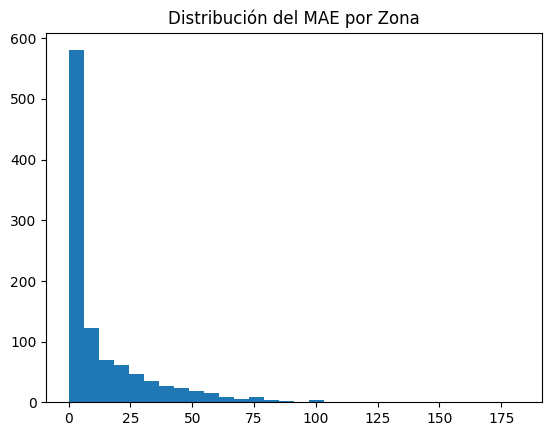

In [ ]:
plt.hist(maes_reales_por_zona, bins=30)
plt.title("Distribución del MAE por Zona")
plt.show()

Prueba extra, simplemente no escalar nada. Probemos esto ya que si va bien nos simplifica mucho las cosas y viedno que es un modelo basado en mlp y autoencoders puede ser que no sufra tanto

In [ ]:
base_path = "../data/data_darts.parquet/"
# Buscamos las carpetas con la nueva clave (ej: Series_ID=0_262)
series_folders = [d for d in os.listdir(base_path) if d.startswith("Series_ID=")]

target_series_list = []
past_covariates_list = []
future_covariates_list = []

for folder in series_folders:
    # Extraemos el Vendor y la Zona del nombre de la carpeta (ej. "0_262")
    # folder es algo como "Series_ID=0_262"
    id_str = folder.split("=")[1] 
    vendor_id, zone_id = id_str.split("_")
    
    # Leemos el parquet de esta combinación específica
    df_serie = pd.read_parquet(Path(base_path, folder))
    df_serie = df_serie.sort_values("timestamp")

    static_covs = pd.DataFrame({
        "VendorID": [float(vendor_id)],
        "PULocationID": [float(zone_id)]
    })
    
    ts_target = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols="demand",
        static_covariates=static_covs,
        freq="h",                      
        fill_missing_dates=True,      
        fillna_value=0.0,              
    )
    target_series_list.append(ts_target)
    
    # 2. Pasadas (Distancia y Precio)
    ts_past = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["avg_distance", "avg_amount"],
        freq="h",
        fill_missing_dates=True,
        fillna_value=0.0             
    )
    past_covariates_list.append(ts_past)
    
    # 3. Futuras (Tiempo trigonométrico)
    ts_future_raw = TimeSeries.from_dataframe(
        df_serie, 
        time_col="timestamp", 
        value_cols=["hour_sin", "hour_cos", "dow_sin", "dow_cos"],
        freq="h",
        fill_missing_dates=True
    )
    
    # Interpolamos los NaN para que la curva trigonométrica siga siendo perfecta
    filler = MissingValuesFiller()
    ts_future = filler.transform(ts_future_raw)
    future_covariates_list.append(ts_future)

print(f"Listas creadas con {len(target_series_list)} series temporales únicas.")

Listas creadas con 1042 series temporales únicas.


Vamos a crear los conjuntos de entrenamiento

In [ ]:
MIN_LENGTH = 300  # Horas mínimas necesarias para que la red neuronal pueda aprender algo
corte_temporal = 0.80

#Vamos a seleccionar solo los datos a partir de 2023, que es el punto en el que se estabiliza la demanda
fecha_inicio = pd.Timestamp("2023-01-01")

train_target, val_target = [], []
train_past, val_past = [], []
train_future, val_future = [], []

series_descartadas = 0

for ts_t, ts_p, ts_f in zip(target_series_list, past_covariates_list, future_covariates_list):
    
    if ts_t.end_time() < fecha_inicio:
        series_descartadas += 1
        continue

    if ts_t.start_time() < fecha_inicio:
        ts_t2 = ts_t.drop_before(fecha_inicio)
        ts_p2 = ts_p.drop_before(fecha_inicio)
        ts_f2 = ts_f.drop_before(fecha_inicio)

    if len(ts_t2) < MIN_LENGTH:
        series_descartadas += 1
        continue

    #Aplicamos log-sqrt

    ts_t2 = ts_t2.map(lambda x: np.log1p(np.sqrt(x)))
    ts_p2 = ts_p2.map(lambda x: np.log1p(np.sqrt(x)))
        
    # Calculamos la FECHA EXACTA del 80%
    punto_de_corte = ts_t2.get_timestamp_at_point(corte_temporal)
    
    # Cortamos las 3 series
    t_train, t_val = ts_t2.split_before(punto_de_corte)
    p_train, p_val = ts_p2.split_before(punto_de_corte)
    f_train, f_val = ts_f2.split_before(punto_de_corte)
    
    # Comprobación de seguridad 
    assert t_train.end_time() == p_train.end_time() == f_train.end_time(), "¡Error! Desalineación detectada."
    
    # Guardamos en las listas
    train_target.append(t_train)
    val_target.append(t_val)
    
    train_past.append(p_train)
    val_past.append(p_val)
    
    train_future.append(f_train)
    val_future.append(f_val)


def safe_float32_conversion(series_list):
    return [ts.astype(np.float32) for ts in series_list]

train_target = safe_float32_conversion(train_target)
train_past   = safe_float32_conversion(train_past)
train_future  = safe_float32_conversion(train_future)

val_target   = safe_float32_conversion(val_target)
val_past     = safe_float32_conversion(val_past)
val_future    = safe_float32_conversion(val_future)
print(f"¡Series divididas!")
print(f"Series válidas para entrenar: {len(train_target)}")
print(f"Series descartadas por ser muy cortas: {series_descartadas}")

¡Series divididas!
Series válidas para entrenar: 1037
Series descartadas por ser muy cortas: 5


In [ ]:
from pytorch_lightning.callbacks import EarlyStopping 

#Creamos el objeto de Tide
print("Inicializando el cerebro TiDE...")

detenedor = EarlyStopping(
    monitor="val_loss",
    patience=4,
    min_delta=0.001,
    mode="min",
)

torch.set_float32_matmul_precision('high') #Esta instrucción activa los cores tensoriales 
modelo_tide = TiDEModel(
    input_chunk_length=96,   
    output_chunk_length=24,  
    num_encoder_layers=2,  
    num_decoder_layers=2,  
    decoder_output_dim=64,
    hidden_size=256,
    dropout=0.25,
    
    use_static_covariates=True, 

    batch_size=1024,          
    n_epochs=15,              
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 0.5,
        "callbacks": [detenedor],
        "precision": "32-true"
    },
    work_dir="darts_models", 
    model_name="tide_nyc_v4",         
    save_checkpoints=True,            
    force_reset=True,   
                  
)
#Entrenamiento
print("¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)")

modelo_tide.fit(
    series=train_target,
    past_covariates=train_past,
    future_covariates=train_future,       
    val_series=val_target,
    val_past_covariates=val_past,
    val_future_covariates=val_future,
    dataloader_kwargs={"num_workers": 8},
    verbose=True  ,                        # Para ver la barra de progreso
)


print("¡Entrenamiento finalizado con éxito!")

number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Inicializando el cerebro TiDE...
¡Arrancando el entrenamiento! (Paciencia, esto va a hacer sudar a tu máquina...)


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ past_cov_projection   │ _ResidualBlock   │  1.8 K │ train │     0 │
│ 6  │ future_cov_projection │ _ResidualBlock   │  2.3 K │ train │     0 │
│ 7  │ encoders              │ Sequential       │  756 K │ train │     0 │
│ 8  │ decoders              │ Sequential       │  1.1 M │ train │     0 │
│ 9  │ temporal_decoder      │ _ResidualBlock   │  2.3 K │ train │     0 │
│ 10 │ lookback_skip         │ Linear           │  2.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

¡Entrenamiento finalizado con éxito!


In [ ]:
import numpy as np
import pandas as pd
import torch
from darts.models import TiDEModel
from darts.utils.statistics import check_seasonal
from darts.dataprocessing.transformers import MissingValuesFiller
from pytorch_lightning.callbacks import EarlyStopping
from darts.utils.likelihood_models import QuantileRegression

# --- CONFIGURACIÓN ---
MIN_LENGTH = 300 
corte_temporal = 0.80
fecha_inicio = pd.Timestamp("2023-01-01")

train_target, val_target = [], []
train_past, val_past = [], []
train_future, val_future = [], []
series_descartadas = 0

print("Procesando series con transformación Log-Sqrt...")

for ts_t, ts_p, ts_f in zip(target_series_list, past_covariates_list, future_covariates_list):
    
    # 1. Filtro de fecha y duración
    if ts_t.end_time() < fecha_inicio:
        series_descartadas += 1
        continue

    # Recorte temporal seguro
    curr_t = ts_t.drop_before(fecha_inicio) if ts_t.start_time() < fecha_inicio else ts_t
    curr_p = ts_p.drop_before(fecha_inicio) if ts_p.start_time() < fecha_inicio else ts_p
    curr_f = ts_f.drop_before(fecha_inicio) if ts_f.start_time() < fecha_inicio else ts_f

    if len(curr_t) < MIN_LENGTH:
        series_descartadas += 1
        continue

    # 2. TRANSFORMACIÓN LOG-SQRT (Nativa y Determinista)
    # Aplicamos a target y past_covs. Future (senos/cosenos) no lo necesita.
    curr_t = curr_t.map(lambda x: np.log1p(np.sqrt(x))).astype(np.float32)
    curr_p = curr_p.map(lambda x: np.log1p(np.sqrt(x))).astype(np.float32)
    curr_f = curr_f.astype(np.float32)
        
    # 3. SPLIT (Corte 80/20)
    punto_de_corte = curr_t.get_timestamp_at_point(corte_temporal)
    
    t_train, t_val = curr_t.split_before(punto_de_corte)
    p_train, p_val = curr_p.split_before(punto_de_corte)
    f_train, f_val = curr_f.split_before(punto_de_corte)
    
    # Guardado directo
    train_target.append(t_train)
    val_target.append(t_val)
    train_past.append(p_train)
    val_past.append(p_val)
    train_future.append(f_train)
    val_future.append(f_val)

print(f"Series listas: {len(train_target)} | Descartadas: {series_descartadas}")

# --- MODELO TiDE PROBABILÍSTICO ---
detenedor = EarlyStopping(
    monitor="val_loss",
    patience=4,
    min_delta=0.0005,
    mode="min",
)

# Definimos cuantiles para poder inferir distribuciones después
# Esto es lo que permite que el modelo sea probabilístico
mi_likelihood = QuantileRegression(per_quantile_loss=False) 

torch.set_float32_matmul_precision('high')

modelo_tide = TiDEModel(
    input_chunk_length=96,   
    output_chunk_length=24,  
    num_encoder_layers=2,   
    num_decoder_layers=2,   
    decoder_output_dim=16, # Reducido para evitar overfitting con Log-Sqrt
    hidden_size=256,
    dropout=0.2,
    
    use_static_covariates=True,
    likelihood=mi_likelihood, # <--- CRÍTICO: Para usar samples/media después

    batch_size=1024,          
    n_epochs=20,              
    optimizer_kwargs={"lr": 1e-3}, 
    random_state=42,         
    
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": -1,
        "gradient_clip_val": 0.5,
        "precision": 32, # 32 estándar para evitar errores de tipos
        "callbacks": [detenedor]
    },
    model_name="tide_nyc_v4_log_sqrt",
    work_dir="darts_models",
    save_checkpoints=True,
    force_reset=True
)

# --- ENTRENAMIENTO ---
print("¡Arrancando el entrenamiento masivo!")
modelo_tide.fit(
    series=train_target,
    past_covariates=train_past,
    future_covariates=train_future,       
    val_series=val_target,
    val_past_covariates=val_past,
    val_future_covariates=val_future,
    dataloader_kwargs={"num_workers": 4}, # Ajustado para no saturar I/O
    verbose=True
)

print("¡Entrenamiento finalizado! Modelo guardado como tide_nyc_v4_log_sqrt")

In [ ]:
import numpy as np
import pandas as pd

# 1. Cargar el modelo (Asegúrate de que el nombre v4 coincide con tu último entrenamiento)
modelo_tide = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_v4",          
    work_dir="darts_models", 
    best=True,                       
    weights_only=False  
)

# 2. Preparar los datos concatenados (Contexto completo para la GPU)
# Usamos las listas que ya tienen aplicado el Log-Sqrt: log(1 + sqrt(x))
target_completo = [t_t.concatenate(v_t) for t_t, v_t in zip(train_target, val_target)]
pasados_completos = [t_p.concatenate(v_p) for t_p, v_p in zip(train_past, val_past)]
futuros_completos = [t_f.concatenate(v_f) for t_f, v_f in zip(train_future, val_future)]

print(f"Lanzando predicción masiva para {len(target_completo)} zonas...")

# 3. PREDICCIÓN MASIVA (Salida en escala Log-Sqrt)
preds_lista = modelo_tide.predict(
    n=24,
    series=[ts[:-24] for ts in target_completo], # Quitamos las últimas 24h para evaluarlas
    past_covariates=pasados_completos, 
    future_covariates=futuros_completos,
    num_samples=100, # Generamos muestras para obtener una mediana robusta
    verbose=True
)

print("Desescalando y calculando MAE en unidades reales de taxis...")

maes_por_zona = []

for i in range(len(preds_lista)):
    # --- PASO A: EXTRAER PREDICCIÓN Y DESESCALAR ---
    # Obtenemos la mediana (P50) de los samples en escala Log-Sqrt
    # Usamos .values() para evitar el overhead de .to_dataframe()
    pred_log_sqrt = preds_lista[i].quantile(0.5).values().flatten()
    
    # Inversa de log(1 + sqrt(x)) -> (exp(y) - 1)^2
    pred_taxis_reales = np.expm1(pred_log_sqrt) ** 2
    
    # --- PASO B: EXTRAER REALIDAD Y DESESCALAR ---
    # val_target ya viene en escala Log-Sqrt del bloque anterior
    real_log_sqrt = val_target[i][:24].values().flatten()
    real_taxis_reales = np.expm1(real_log_sqrt) ** 2
    
    # --- PASO C: CÁLCULO DEL ERROR ---
    if len(pred_taxis_reales) == len(real_taxis_reales):
        error = np.mean(np.abs(real_taxis_reales - pred_taxis_reales))
        maes_por_zona.append(error)

# 4. RESULTADOS GLOBALES
mae_global = np.mean(maes_por_zona)
mediana_mae = np.median(maes_por_zona)

print("\n==================================================")
print("REPORTE FINAL: VALIDACIÓN MASIVA (LOG-SQRT)")
print("==================================================")
print(f"MAE Promedio Global: {mae_global:.2f} taxis de error.")
print(f"Mediana del MAE:     {mediana_mae:.2f} taxis de error.")
print("==================================================")

Lanzando predicción masiva para 1037 zonas...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generating TimeSeries:   0%|          | 0/1037 [00:00<?, ?it/s]

Desescalando y calculando MAE en unidades reales de taxis...

REPORTE FINAL: VALIDACIÓN MASIVA (LOG-SQRT)
MAE Promedio Global: 12.90 taxis de error.
Mediana del MAE:     3.59 taxis de error.


Como vemos, los modelos dan problemas al inferir, esto debido a que la extructura de listas no es la más adecuada. En vez de hacer transformaciones manuales, darts ofrece sus propias herramientas para entrenar con df de pandas. Además se pueden usar medias moviles dinámicas, por tanto simplemente haciendo el logaritmo de los datos no tendriamos problemas de escalas. Además la distribucion de la demanda es claramente asimétrica, muy pocas zonas tienen demanda real y la mayoria tienen  demanda nula, por tanto separar los datos con un kmeans y crear tres modelos permitira segmentar el problema. Por último darts a diferencia de pytorch forecasting no usa embeddings, por tanto, al igual que con la lstm deberemos usar los centroides y el one hot de los servicios

In [ ]:
df_pd = pd.read_parquet("../data/data_darts.parquet")

# Es vital que los datos estén ordenados temporalmente dentro de cada grupo
df_pd = df_pd.sort_values(by=["Series_ID", "timestamp"])

fecha_limite = df_pd['timestamp'].max() - pd.DateOffset(years=3)
df_pd = df_pd[df_pd['timestamp'] >= fecha_limite].copy()


# LATITUD Y LONGITUD (Escalado espacial)
# Escalamos las coordenadas entre 0 y 1 en Pandas para que TiDE las digiera perfecto
scaler_espacial = MinMaxScaler()
cols_geo = ["Latitude", "Longitude"]

df_pd[cols_geo] = scaler_espacial.fit_transform(df_pd[cols_geo])
df_pd[cols_geo] = df_pd[cols_geo].astype("float32")

#VARIABLES NUMÉRICAS (Float32)
cols_numericas = ["demand", "avg_distance", "avg_amount"]
df_pd[cols_numericas] = df_pd[cols_numericas].astype("float32")

print("Aplicando One-Hot Encoding a VendorID...")

encoder_vendor = SklearnOneHotEncoder(sparse_output=False,drop='first', handle_unknown='ignore')


dummies_array = encoder_vendor.fit_transform(df_pd[['VendorID']])

nombres_dummies = encoder_vendor.get_feature_names_out(['VendorID'])

df_pd[nombres_dummies] = dummies_array

df_pd["VendorID"] = df_pd["VendorID"].astype("float32") # Mantenemos el original para Darts

columnas_estaticas = list(nombres_dummies) + ["Latitude", "Longitude"]

print(f"Variables estáticas que verá el modelo: {columnas_estaticas}")

df_pd[columnas_estaticas] = df_pd[columnas_estaticas].astype("float32")

print(f"Variables estáticas que verá el modelo: {columnas_estaticas}")

# =============================================
# SEGMENTACIÓN DE ZONAS (K-MEANS AUTOMÁTICO)
# =============================================
print("\nCalculando segmentos automáticamente con Inteligencia Artificial (K-Means)...")

# 1. Calculamos el volumen medio real de cada serie a lo largo del tiempo
volumen_series = df_pd.groupby('Series_ID')['demand'].mean().reset_index()

# 2. K-Means al rescate (pedimos que encuentre los 3 grupos más naturales)
X = volumen_series['demand'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
volumen_series['cluster_id'] = kmeans.fit_predict(X)

# 3. Ordenar los clusters porque K-Means asigna los números (0, 1, 2) al azar
centros = kmeans.cluster_centers_.flatten()
orden_clusters = np.argsort(centros) # Ordena los índices de menor a mayor centroide

# 4. Mapear los índices ordenados a nuestras etiquetas reales
mapa_clusters = {
    orden_clusters[0]: 'BASELINE', # El centroide con menor volumen
    orden_clusters[1]: 'MID',      # El centroide intermedio
    orden_clusters[2]: 'HIGH'      # El centroide de los titanes de Manhattan
}
volumen_series['segmento'] = volumen_series['cluster_id'].map(mapa_clusters)

# 5. Extraer las listas de identificadores para cada grupo
series_baseline = volumen_series[volumen_series['segmento'] == 'BASELINE']['Series_ID'].values
series_medias   = volumen_series[volumen_series['segmento'] == 'MID']['Series_ID'].values
series_altas    = volumen_series[volumen_series['segmento'] == 'HIGH']['Series_ID'].values

print("\n🎯 RESULTADOS DE LA SEGMENTACIÓN MATEMÁTICA (Sin Umbrales Manuales):")
for seg in ['BASELINE', 'MID', 'HIGH']:
    df_seg = volumen_series[volumen_series['segmento'] == seg]
    min_v = df_seg['demand'].min()
    max_v = df_seg['demand'].max()
    print(f"   - {seg}: {len(df_seg)} zonas (Rango matemático: de {min_v:.2f} a {max_v:.2f} viajes/h de media)")

# 6. Crear los DataFrames físicos segmentados
df_baseline = df_pd[df_pd['Series_ID'].isin(series_baseline)].copy()
df_medias   = df_pd[df_pd['Series_ID'].isin(series_medias)].copy()
df_altas    = df_pd[df_pd['Series_ID'].isin(series_altas)].copy()

col_tiempo = "timestamp"
col_grupo = ["PULocationID", "VendorID"]

#######
#Preparam,os un calendario global para que todas las series tengan el mismo rango temporal, incluso si hay huecos
#######

col_tiempo = "timestamp"
col_grupo = ["PULocationID", "VendorID"]

# 1. CREAMOS EL CALENDARIO MAESTRO (Una sola vez para todo el proyecto)
print("Generando Calendario Maestro de Covariables Futuras...")
HORAS_EXTRA = 48
inicio_global = df_pd['timestamp'].min()
fin_global = df_pd['timestamp'].max() + pd.Timedelta(hours=HORAS_EXTRA)

# Rango que cubre absolutamente todo el dataset + 48h de futuro
indice_global = pd.date_range(start=inicio_global, end=fin_global, freq='h')

cov_hora_global = datetime_attribute_timeseries(indice_global, attribute="hour", cyclic=True)
cov_dia_global = datetime_attribute_timeseries(indice_global, attribute="dayofweek", cyclic=True)
calendario_maestro = cov_hora_global.stack(cov_dia_global).astype("float32")

def preparar_dataset_darts(df_segmento, nombre_segmento):
    """Convierte un DataFrame de Pandas en las 3 listas de TimeSeries para TiDE"""
    if df_segmento.empty:
        return [], [], []
        
    
    # TARGETS
    targets = TimeSeries.from_group_dataframe(
        df_segmento, group_cols=col_grupo, time_col=col_tiempo, value_cols="demand",
        static_cols=columnas_estaticas, fill_missing_dates=True, freq='h', fillna_value=0           
    )
    
    # PAST COVARIATES
    past_covs = TimeSeries.from_group_dataframe(
        df_segmento, group_cols=col_grupo, time_col=col_tiempo, value_cols=["avg_distance", "avg_amount"],
        fill_missing_dates=True, freq='h', fillna_value=0           
    )
    
    future_covs = [calendario_maestro] * len(targets)

    return targets, past_covs, future_covs



# 1. Datos para el TiDE Ligero
targets_mid, past_mid, future_mid = preparar_dataset_darts(df_medias, "Media Demanda")

# 2. Datos para el TiDE Pesado
targets_high, past_high, future_high = preparar_dataset_darts(df_altas, "Alta Demanda")
# 3. Datos para el TiDE Baseline

targets_baseline, past_baseline, future_baseline = preparar_dataset_darts(df_baseline, "Baseline")

Aplicando One-Hot Encoding a VendorID...
Variables estáticas que verá el modelo: ['VendorID_1', 'VendorID_2', 'VendorID_3', 'Latitude', 'Longitude']
Variables estáticas que verá el modelo: ['VendorID_1', 'VendorID_2', 'VendorID_3', 'Latitude', 'Longitude']

Calculando segmentos automáticamente con Inteligencia Artificial (K-Means)...

🎯 RESULTADOS DE LA SEGMENTACIÓN MATEMÁTICA (Sin Umbrales Manuales):
   - BASELINE: 739 zonas (Rango matemático: de 1.00 a 35.26 viajes/h de media)
   - MID: 220 zonas (Rango matemático: de 35.93 a 113.79 viajes/h de media)
   - HIGH: 80 zonas (Rango matemático: de 116.37 a 381.50 viajes/h de media)
Generando Calendario Maestro de Covariables Futuras...


Guardamos los centroides

In [ ]:
import json
import os

print("\n💾 Guardando el Enrutador de Producción (Router)...")

# 1. Creamos la carpeta para los artefactos de producción (si no existe)
CARPETA_ARTEFACTOS = "darts_models" # Puedes usar la misma donde guardas los modelos
os.makedirs(CARPETA_ARTEFACTOS, exist_ok=True)

# 2. Convertimos las columnas a un diccionario de Python
# Formato resultante: { 138: "HIGH", 4: "BASELINE", ... }
mapa_enrutamiento = dict(zip(volumen_series['Series_ID'].astype(str), volumen_series['segmento']))

# 3. Guardamos el diccionario como un archivo JSON
ruta_json = os.path.join(CARPETA_ARTEFACTOS, "router_zonas.json")

with open(ruta_json, "w") as archivo:
    json.dump(mapa_enrutamiento, archivo, indent=4)

print(f"✅ ¡Router guardado con éxito en '{ruta_json}'!")
print(f"🗺️ Zonas mapeadas: {len(mapa_enrutamiento)}")


💾 Guardando el Enrutador de Producción (Router)...
✅ ¡Router guardado con éxito en 'darts_models/router_zonas.json'!
🗺️ Zonas mapeadas: 1039


Guardamos el onehot encoder

In [ ]:
import joblib
import os

CARPETA_ARTEFACTOS = "darts_models"
os.makedirs(CARPETA_ARTEFACTOS, exist_ok=True)

print("💾 Guardando transformadores de preprocesamiento...")

# Guardamos el One-Hot Encoder
joblib.dump(encoder_vendor, f"{CARPETA_ARTEFACTOS}/encoder_vendor.pkl")

# Guardamos el Scaler Espacial (Lat/Lon)
joblib.dump(scaler_espacial, f"{CARPETA_ARTEFACTOS}/scaler_espacial.pkl")

print("✅ Artefactos guardados con éxito.")

💾 Guardando transformadores de preprocesamiento...
✅ Artefactos guardados con éxito.


In [4]:
from darts.dataprocessing.transformers import InvertibleMapper, Mapper
from darts.dataprocessing.pipeline import Pipeline
import numpy as np
import pandas as pd

# ==========================================
# DIVISIÓN TRAIN/VAL Y TRANSFORMACIÓN (MODULAR)
# ==========================================
CORTE = pd.Timestamp("2025-11-20 00:00:00") 
VENTANA_TRAIN = 96 # 72h input + 24h output
VENTANA_VAL = 168   # Evaluamos solo 1 día para evitar el error de horizonte lejano

def preparar_entrenamiento(targets, past, future, nombre_segmento):
    """
    Filtra, divide y aplica las transformaciones.
    Construye las series de validación con el contexto histórico necesario (72h).
    """
    if not targets:
        return {}, {}, None, None

    print(f"\nDividiendo datos y aplicando pipelines para: {nombre_segmento}...")

    INPUT_CHUNK = 72
    OUTPUT_CHUNK = 24

    tr_tgt, val_tgt = [], []
    tr_pst, val_pst = [], []
    tr_fut, val_fut = [], []

    zonas_descartadas = 0

    for tgt, pst, fut in zip(targets, past, future):
        
        # 1. ESCUDO: ¿Hay datos a ambos lados del corte?
        if tgt.start_time() < CORTE and (tgt.end_time() - CORTE).days >= 1:
            
            # Cortamos por la fecha exacta SOLO para ver la longitud del train
            tr_t_temp, ts_t_temp = tgt.split_before(CORTE)
            
            # 2. ESCUDO: ¿Tiene el tamaño mínimo? (Train > 72, Val > 24)
            if len(tr_t_temp) >= INPUT_CHUNK and len(ts_t_temp) >= OUTPUT_CHUNK:
                
                # Obtenemos el índice numérico exacto del corte
                idx = len(tr_t_temp) 
                
                # TRAIN: Todo desde el inicio hasta el corte (como siempre)
                tr_tgt.append(tgt[:idx])
                tr_pst.append(pst[:idx])
                
                # VALIDACIÓN: 72h antes del corte + 24h después del corte = 96h
        
                val_tgt.append(tgt[idx - INPUT_CHUNK : idx + VENTANA_VAL])
                val_pst.append(pst[idx - INPUT_CHUNK : idx + VENTANA_VAL])

                #El futuro es todo
                tr_fut.append(fut) 
                val_fut.append(fut)
                
                
            else:
                zonas_descartadas += 1
        else:
            zonas_descartadas += 1

    print(f"{nombre_segmento}: {len(tr_tgt)} series válidas listas. Descartadas: {zonas_descartadas}")

    if not tr_tgt:
        return {}, {}, None,None

    # ==========================================
    # PIPELINES (Log1p)
    # ==========================================
    target_pipeline = Pipeline([InvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)])
    past_pipeline = Pipeline([Mapper(fn=np.log1p)])

    dict_train = {
        "targets": target_pipeline.fit_transform(tr_tgt),
        "past": past_pipeline.fit_transform(tr_pst),
        "future": tr_fut 
    }
    
    dict_val = {
        "targets_real": val_tgt, 
        "targets": target_pipeline.transform(val_tgt),
        "past": past_pipeline.transform(val_pst),
        "future": val_fut
    }
    return dict_train, dict_val, target_pipeline, past_pipeline

# ==========================================
# EJECUTAR PARA NUESTROS SEGMENTOS
# ==========================================
train_high, val_high, pipe_high, pipe_past_high = preparar_entrenamiento(targets_high, past_high, future_high, "ALTA Demanda")
train_mid, val_mid, pipe_mid, pipe_past_mid = preparar_entrenamiento(targets_mid, past_mid, future_mid, "MEDIA Demanda")
train_baseline, val_baseline, pipe_base, pipe_past_base = preparar_entrenamiento(targets_baseline, past_baseline, future_baseline, "BASELINE")

print("\n¡Todos los datos están listos y empaquetados para entrenar!")


Dividiendo datos y aplicando pipelines para: ALTA Demanda...
ALTA Demanda: 80 series válidas listas. Descartadas: 0

Dividiendo datos y aplicando pipelines para: MEDIA Demanda...
MEDIA Demanda: 220 series válidas listas. Descartadas: 0

Dividiendo datos y aplicando pipelines para: BASELINE...
BASELINE: 693 series válidas listas. Descartadas: 46

¡Todos los datos están listos y empaquetados para entrenar!


In [ ]:

from torch.nn import HuberLoss
torch.set_float32_matmul_precision('high') 
# ==========================================
# ESPECIALISTA 1: ALTA DEMANDA (El Modelo Pesado)
# ==========================================
if train_high["targets"]:
    print("\n" + "="*50)
    print("ENTRENANDO ESPECIALISTA: ALTA DEMANDA")
    print("="*50)

    detenedor_high = EarlyStopping(
        monitor="val_loss",
        patience=6,
        min_delta=0.001,
        mode="min",
    )

    modelo_high = TiDEModel(
        input_chunk_length=72,   
        output_chunk_length=24,  
        
        # Arquitectura pesada para absorber picos gigantes
        num_encoder_layers=3,  
        num_decoder_layers=3,  
        decoder_output_dim=128,
        hidden_size=512,         
        dropout=0.20, 
        
        use_static_covariates=True, 
        use_reversible_instance_norm=True, 

        batch_size=256,          
        n_epochs=40,              
        optimizer_kwargs={"lr": 1e-4}, 
        random_state=42,         
        
        likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),
        
        pl_trainer_kwargs={
            "accelerator": "gpu",
            "devices": -1,
            "gradient_clip_val": 0.5, 
            "callbacks": [detenedor_high],
            "precision": "32-true"
        },
        
        # MLOps
        work_dir="darts_models", 
        model_name="tide_nyc_alta_v5_beta",        
        save_checkpoints=True,            
        force_reset=True,   
    )

    modelo_high.fit(
        series=train_high["targets"],              
        past_covariates=train_high["past"],        
        future_covariates=train_high["future"],        
        val_series=val_high["targets"],            
        val_past_covariates=val_high["past"],      
        val_future_covariates=val_high["future"],      
        dataloader_kwargs={"num_workers": 8},
        verbose=True,                        
    )

number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



ENTRENANDO ESPECIALISTA: ALTA DEMANDA


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ rin                   │ RINorm           │      2 │ train │     0 │
│ 6  │ past_cov_projection   │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 7  │ future_cov_projection │ _ResidualBlock   │  4.6 K │ train │     0 │
│ 8  │ encoders              │ Sequential       │  2.6 M │ train │     0 │
│ 9  │ decoders              │ Sequential       │ 11.3 M │ train │     0 │
│ 10 │ temporal_decoder      │ _ResidualBlock   │ 13.7 K │ train │     0 │
│ 11 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 13.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.9 M                                                                                               
Total estimated model params size (MB): 55                                                                         
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

In [ ]:
series_altas

['0_132', '0_138', '0_142', '0_161', '0_162', ..., '2_90', '2_95', '2_97', '3_132', '3_138']
Length: 80
Categories (1042, str): ['0_1', '0_10', '0_100', '0_101', ..., '3_96', '3_97', '3_98', '3_99']

Cargando el mejor checkpoint del especialista de Alta Demanda...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Buscando la serie correspondiente a la Zona 161 y Vendor 0...
✅ Serie encontrada en el índice 45. Generando predicción probabilística...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



🎯 MAE (Zona 161 | Vendor 0): 28.34 viajes/hora


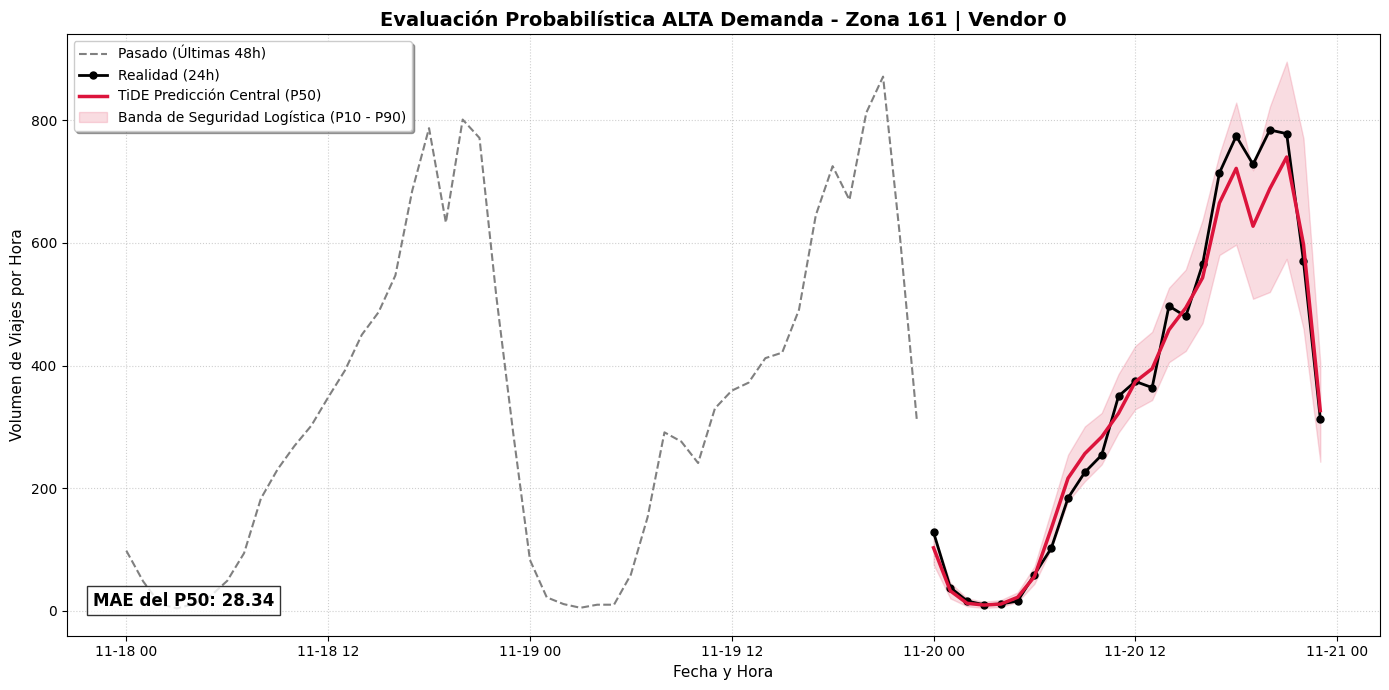

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from darts.metrics import mae
from darts.models import TiDEModel

# --- CONFIGURACIÓN ---
ZONA_Buscada = 161 # La Guardia Airport (¡Un clásico de alta demanda!)
VENDOR_Buscado = 0  # 0 = Creative Mobile o 1 = VeriFone, según tu One-Hot
HORIZONTE = 24      # Predicción a 24 horas

print("Cargando el mejor checkpoint del especialista de Alta Demanda...")
# 1. Cargar el modelo específico de Alta Demanda
modelo_high = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_alta_v5", 
    work_dir="darts_models",
    best=True,
    weights_only=False
)

print(f"Buscando la serie correspondiente a la Zona {ZONA_Buscada} y Vendor {VENDOR_Buscado}...")

# 2. Encontrar el índice en la lista de ALTA demanda
idx_target = -1
for i, serie in enumerate(train_high["targets"]):
    estaticas = serie.static_covariates
    if estaticas is not None:
        zona_actual = int(estaticas['PULocationID'].iloc[0])
        vendor_actual = int(estaticas['VendorID'].iloc[0])
        
        if zona_actual == ZONA_Buscada and vendor_actual == VENDOR_Buscado:
            idx_target = i
            break

if idx_target == -1:
    print(f"❌ No se encontró la Zona {ZONA_Buscada} con Vendor {VENDOR_Buscado} en el segmento ALTO.")
    print("Intenta buscarla en el segmento MEDIO o BASELINE.")
else:
    print(f"✅ Serie encontrada en el índice {idx_target}. Generando predicción probabilística...")

    # 3. Generar Predicción con el modelo
    # 3. Generar Predicción Probabilística con el modelo
    # 🔥 LA LLAVE MAESTRA: Añadimos num_samples para activar las simulaciones estocásticas
    pred_tf = modelo_high.predict(
        n=HORIZONTE,
        series=train_high["targets"][idx_target],
        past_covariates=train_high["past"][idx_target],
        future_covariates=future_high[idx_target],
        num_samples=200 # Darts simulará 200 futuros basados en tus cuantiles
    )

    # 4. Revertir la transformación logarítmicaInvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)
    pred_real = pipe_high.inverse_transform(pred_tf)
    
    # --- MAGIA MLOPS: EXTRACCIÓN DE CUANTILES (NUEVA API) ---
    pred_p10 = pred_real.quantile(0.10) # El escenario pesimista
    pred_p50 = pred_real.quantile(0.50) # El escenario central (Mediana)
    pred_p90 = pred_real.quantile(0.90) # El escenario de alta demanda
    
    # 5. Alinear la realidad
    serie_real_completa = val_high["targets_real"][idx_target]
    actual_real = serie_real_completa.slice_intersect(pred_p50)

    # 6. Calcular MAE usando el escenario central (P50)
    error_mae = mae(actual_real, pred_p50)
    print("\n" + "="*50)
    print(f"🎯 MAE (Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}): {error_mae:.2f} viajes/hora")
    print("="*50)

    # 7. Preparar datos para Visualización (Pasamos a Pandas de forma segura)
    df_p10 = pred_p10.to_dataframe()
    df_p50 = pred_p50.to_dataframe()
    df_p90 = pred_p90.to_dataframe()
    
    df_real = actual_real.to_dataframe()
    df_contexto = pipe_high.inverse_transform(train_high["targets"][idx_target][-48:]).to_dataframe()

    # 8. Visualización MLOps con Bandas de Confianza
    plt.figure(figsize=(14, 7))
    
    # A. Contexto Histórico
    plt.plot(df_contexto.index, df_contexto.iloc[:, 0], label='Pasado (Últimas 48h)', color='gray', linestyle='--')
    
    # B. Realidad Oculta
    plt.plot(df_real.index, df_real.iloc[:, 0], label='Realidad (24h)', color='black', marker='o', linewidth=2, markersize=5)
    
    # C. Predicción Central (P50)
    plt.plot(df_p50.index, df_p50.iloc[:, 0], label='TiDE Predicción Central (P50)', color='crimson', linewidth=2.5)
    
    # D. Bandas de Confianza (P10 - P90)
    # Extraemos los valores como arrays 1D (iloc[:, 0]) para que matplotlib lo dibuje perfecto
    plt.fill_between(
        df_p50.index, 
        df_p10.iloc[:, 0], 
        df_p90.iloc[:, 0], 
        color='crimson', 
        alpha=0.15, 
        label='Banda de Seguridad Logística (P10 - P90)'
    )

    # Estilos
    plt.title(f"Evaluación Probabilística ALTA Demanda - Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}", fontsize=14, fontweight='bold')
    plt.xlabel("Fecha y Hora", fontsize=11)
    plt.ylabel("Volumen de Viajes por Hora", fontsize=11)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir el MAE como texto en el gráfico
    plt.text(
        0.02, 0.05, f"MAE del P50: {error_mae:.2f}", 
        transform=plt.gca().transAxes, 
        fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

Ahora entrenamos el de los datos medios

In [ ]:

from torch.nn import HuberLoss
torch.set_float32_matmul_precision('high') 
# ==========================================
# ESPECIALISTA 2: Media DEMANDA (El Modelo medio)
# ==========================================
if train_mid["targets"]:
    print("\n" + "="*50)
    print("ENTRENANDO ESPECIALISTA: Media DEMANDA")
    print("="*50)

    detenedor_mid = EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=0.001,
        mode="min",
    )

    modelo_mid = TiDEModel(
        input_chunk_length=72,   
        output_chunk_length=24,  
        
        # Arquitectura pesada para absorber picos gigantes
        num_encoder_layers=3,  
        num_decoder_layers=3,  
        decoder_output_dim=128,
        hidden_size=512,         
        dropout=0.15, 
        
        use_static_covariates=True, 
        use_reversible_instance_norm=True, 

        batch_size=512,          
        n_epochs=40,              
        optimizer_kwargs={"lr": 1e-3}, 
        random_state=42,         
        
        likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),
        
        pl_trainer_kwargs={
            "accelerator": "gpu",
            "devices": -1,
            "gradient_clip_val": 0.5, 
            "callbacks": [detenedor_mid],
            "precision": "32-true"
        },
        
        # MLOps
        work_dir="darts_models", 
        model_name="tide_nyc_media_v5",        
        save_checkpoints=True,            
        force_reset=True,   
    )

    modelo_mid.fit(
        series=train_mid["targets"],              
        past_covariates=train_mid["past"],        
        future_covariates=train_mid["future"],        
        val_series=val_mid["targets"],            
        val_past_covariates=val_mid["past"],      
        val_future_covariates=val_mid["future"],      
        dataloader_kwargs={"num_workers": 8},
        verbose=True,                        
    )

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/torch/__init__.py:1659: UserWarning: mid is not one of 'highest', 'high', or 'medium'; the currentsetFloat32MatmulPrecision call has no effect. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:397.)
  _C._set_float32_matmul_precision(precision)
number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



ENTRENANDO ESPECIALISTA: Media DEMANDA


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ rin                   │ RINorm           │      2 │ train │     0 │
│ 6  │ past_cov_projection   │ _ResidualBlock   │  3.6 K │ train │     0 │
│ 7  │ future_cov_projection │ _ResidualBlock   │  4.6 K │ train │     0 │
│ 8  │ encoders              │ Sequential       │  2.6 M │ train │     0 │
│ 9  │ decoders              │ Sequential       │ 11.3 M │ train │     0 │
│ 10 │ temporal_decoder      │ _ResidualBlock   │ 13.7 K │ train │     0 │
│ 11 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 13.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.9 M                                                                                               
Total estimated model params size (MB): 55                                                                         
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

Cargando el mejor checkpoint del especialista de Media Demanda...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Buscando la serie correspondiente a la Zona 90 y Vendor 3...
✅ Serie encontrada en el índice 68. Generando predicción probabilística...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



🎯 MAE (Zona 90 | Vendor 3): 6.14 viajes/hora


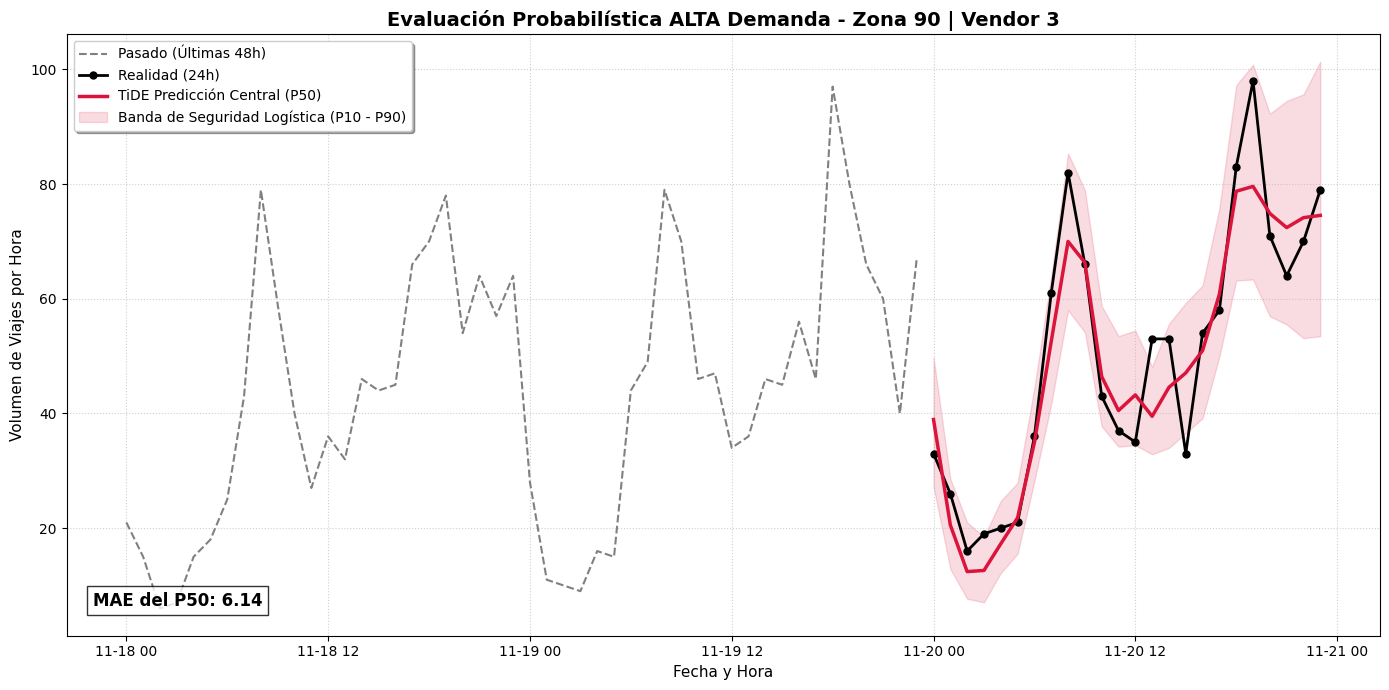

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from darts.metrics import mae
from darts.models import TiDEModel

# --- CONFIGURACIÓN ---
ZONA_Buscada = 90 
VENDOR_Buscado = 3 
HORIZONTE = 24      # Predicción a 24 horas

print("Cargando el mejor checkpoint del especialista de Media Demanda...")
# 1. Cargar el modelo específico de Media Demanda
modelo_mid = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_media_v5", 
    work_dir="darts_models",
    best=True,
    weights_only=False
)

print(f"Buscando la serie correspondiente a la Zona {ZONA_Buscada} y Vendor {VENDOR_Buscado}...")

# 2. Encontrar el índice en la lista de ALTA demanda
idx_target = -1
for i, serie in enumerate(train_mid["targets"]):
    estaticas = serie.static_covariates
    if estaticas is not None:
        zona_actual = int(estaticas['PULocationID'].iloc[0])
        vendor_actual = int(estaticas['VendorID'].iloc[0])
        
        if zona_actual == ZONA_Buscada and vendor_actual == VENDOR_Buscado:
            idx_target = i
            break

if idx_target == -1:
    print(f"❌ No se encontró la Zona {ZONA_Buscada} con Vendor {VENDOR_Buscado} en el segmento ALTO.")
    print("Intenta buscarla en el segmento MEDIO o BASELINE.")
else:
    print(f"✅ Serie encontrada en el índice {idx_target}. Generando predicción probabilística...")

    # 3. Generar Predicción con el modelo
    # 3. Generar Predicción Probabilística con el modelo
    # 🔥 LA LLAVE MAESTRA: Añadimos num_samples para activar las simulaciones estocásticas
    pred_tf = modelo_mid.predict(
        n=HORIZONTE,
        series=train_mid["targets"][idx_target],
        past_covariates=train_mid["past"][idx_target],
        future_covariates=future_mid[idx_target],
        num_samples=200 # Darts simulará 200 futuros basados en tus cuantiles
    )

    # 4. Revertir la transformación logarítmicaInvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)
    pred_real = pipe_mid.inverse_transform(pred_tf)
    
    # --- MAGIA MLOPS: EXTRACCIÓN DE CUANTILES (NUEVA API) ---
    pred_p10 = pred_real.quantile(0.10) # El escenario pesimista
    pred_p50 = pred_real.quantile(0.50) # El escenario central (Mediana)
    pred_p90 = pred_real.quantile(0.90) # El escenario de alta demanda
    
    # 5. Alinear la realidad
    serie_real_completa = val_mid["targets_real"][idx_target]
    actual_real = serie_real_completa.slice_intersect(pred_p50)

    # 6. Calcular MAE usando el escenario central (P50)
    error_mae = mae(actual_real, pred_p50)
    print("\n" + "="*50)
    print(f"🎯 MAE (Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}): {error_mae:.2f} viajes/hora")
    print("="*50)

    # 7. Preparar datos para Visualización (Pasamos a Pandas de forma segura)
    df_p10 = pred_p10.to_dataframe()
    df_p50 = pred_p50.to_dataframe()
    df_p90 = pred_p90.to_dataframe()
    
    df_real = actual_real.to_dataframe()
    df_contexto = pipe_mid.inverse_transform(train_mid["targets"][idx_target][-48:]).to_dataframe()

    # 8. Visualización MLOps con Bandas de Confianza
    plt.figure(figsize=(14, 7))
    
    # A. Contexto Histórico
    plt.plot(df_contexto.index, df_contexto.iloc[:, 0], label='Pasado (Últimas 48h)', color='gray', linestyle='--')
    
    # B. Realidad Oculta
    plt.plot(df_real.index, df_real.iloc[:, 0], label='Realidad (24h)', color='black', marker='o', linewidth=2, markersize=5)
    
    # C. Predicción Central (P50)
    plt.plot(df_p50.index, df_p50.iloc[:, 0], label='TiDE Predicción Central (P50)', color='crimson', linewidth=2.5)
    
    # D. Bandas de Confianza (P10 - P90)
    # Extraemos los valores como arrays 1D (iloc[:, 0]) para que matplotlib lo dibuje perfecto
    plt.fill_between(
        df_p50.index, 
        df_p10.iloc[:, 0], 
        df_p90.iloc[:, 0], 
        color='crimson', 
        alpha=0.15, 
        label='Banda de Seguridad Logística (P10 - P90)'
    )

    # Estilos
    plt.title(f"Evaluación Probabilística ALTA Demanda - Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}", fontsize=14, fontweight='bold')
    plt.xlabel("Fecha y Hora", fontsize=11)
    plt.ylabel("Volumen de Viajes por Hora", fontsize=11)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir el MAE como texto en el gráfico
    plt.text(
        0.02, 0.05, f"MAE del P50: {error_mae:.2f}", 
        transform=plt.gca().transAxes, 
        fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

tambien hacemos el ligero

In [ ]:

from torch.nn import HuberLoss
torch.set_float32_matmul_precision('medium') 
# ==========================================
# ESPECIALISTA 2: Baja DEMANDA (El Modelo bajo)
# ==========================================
if train_baseline["targets"]:
    print("\n" + "="*50)
    print("ENTRENANDO ESPECIALISTA: Baja DEMANDA")
    print("="*50)

    detenedor_baseline = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=0.001,
        mode="min",
    )

    modelo_baseline = TiDEModel(
        input_chunk_length=72,   
        output_chunk_length=24,  
        
        # Arquitectura pesada para absorber picos gigantes
        num_encoder_layers=1,  
        num_decoder_layers=1,  
        decoder_output_dim=64,
        hidden_size=256,         
        dropout=0.15, 
        
        use_static_covariates=True, 
        use_reversible_instance_norm=True, 

        batch_size=512,          
        n_epochs=40,              
        optimizer_kwargs={"lr": 1e-3}, 
        random_state=42,         
        
        likelihood=QuantileRegression(quantiles=[0.10, 0.50, 0.90]),
        
        pl_trainer_kwargs={
            "accelerator": "gpu",
            "devices": -1,
            "gradient_clip_val": 0.5, 
            "callbacks": [detenedor_baseline],
            "precision": "32-true"
        },
        
        # MLOps
        work_dir="darts_models", 
        model_name="tide_nyc_baseline_v5",        
        save_checkpoints=True,            
        force_reset=True,   
    )

    modelo_baseline.fit(
        series=train_baseline["targets"],              
        past_covariates=train_baseline["past"],        
        future_covariates=train_baseline["future"],        
        val_series=val_baseline["targets"],            
        val_past_covariates=val_baseline["past"],      
        val_future_covariates=val_baseline["future"],      
        dataloader_kwargs={"num_workers": 8},
        verbose=True,                        
    )

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/torch/__init__.py:1659: UserWarning: baseline is not one of 'highest', 'high', or 'medium'; the currentsetFloat32MatmulPrecision call has no effect. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:397.)
  _C._set_float32_matmul_precision(precision)
number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



ENTRENANDO ESPECIALISTA: Media DEMANDA


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ rin                   │ RINorm           │      2 │ train │     0 │
│ 6  │ past_cov_projection   │ _ResidualBlock   │  1.8 K │ train │     0 │
│ 7  │ future_cov_projection │ _ResidualBlock   │  2.3 K │ train │     0 │
│ 8  │ encoders              │ Sequential       │  450 K │ train │     0 │
│ 9  │ decoders              │ Sequential       │  2.4 M │ train │     0 │
│ 10 │ temporal_decoder      │ _ResidualBlock   │  7.0 K │ train │     0 │
│ 11 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 44                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Guardamos todo

Guardamos las particiones de cada modelo

In [ ]:
series_baseline 

['0_1', '0_10', '0_101', '0_102', '0_105', ..., '3_93', '3_94', '3_96', '3_98', '3_99']
Length: 739
Categories (1042, str): ['0_1', '0_10', '0_100', '0_101', ..., '3_96', '3_97', '3_98', '3_99']

Cargando el mejor checkpoint del especialista de Media Demanda...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Buscando la serie correspondiente a la Zona 93 y Vendor 3...
✅ Serie encontrada en el índice 260. Generando predicción probabilística...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



🎯 MAE (Zona 93 | Vendor 3): 1.23 viajes/hora


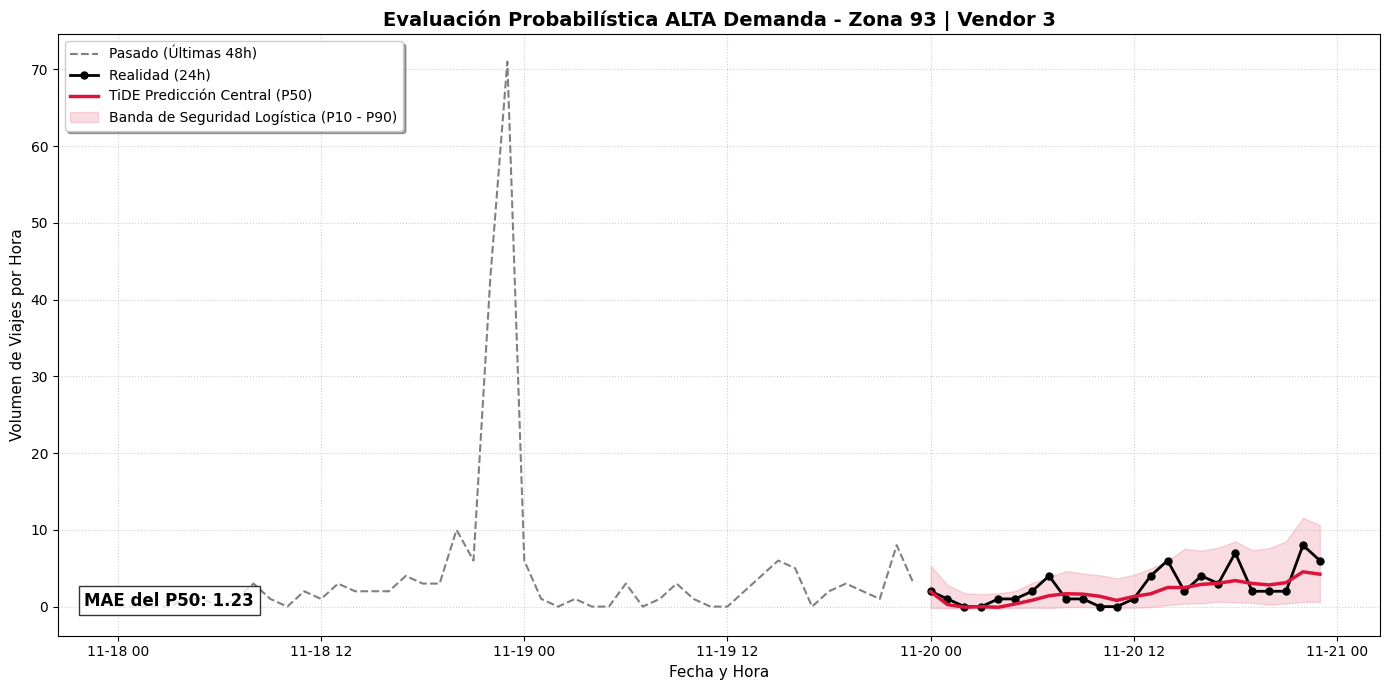

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from darts.metrics import mae
from darts.models import TiDEModel

# --- CONFIGURACIÓN ---
ZONA_Buscada = 93
VENDOR_Buscado = 3
HORIZONTE = 24      # Predicción a 24 horas

print("Cargando el mejor checkpoint del especialista de Media Demanda...")
# 1. Cargar el modelo específico de Media Demanda
modelo_baseline = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_baseline_v5", 
    work_dir="darts_models",
    best=True,
    weights_only=False
)

print(f"Buscando la serie correspondiente a la Zona {ZONA_Buscada} y Vendor {VENDOR_Buscado}...")

# 2. Encontrar el índice en la lista de ALTA demanda
idx_target = -1
for i, serie in enumerate(train_baseline["targets"]):
    estaticas = serie.static_covariates
    if estaticas is not None:
        zona_actual = int(estaticas['PULocationID'].iloc[0])
        vendor_actual = int(estaticas['VendorID'].iloc[0])
        
        if zona_actual == ZONA_Buscada and vendor_actual == VENDOR_Buscado:
            idx_target = i
            break

if idx_target == -1:
    print(f"❌ No se encontró la Zona {ZONA_Buscada} con Vendor {VENDOR_Buscado} en el segmento ALTO.")
    print("Intenta buscarla en el segmento MEDIO o BASELINE.")
else:
    print(f"✅ Serie encontrada en el índice {idx_target}. Generando predicción probabilística...")

    # 3. Generar Predicción con el modelo
    # 3. Generar Predicción Probabilística con el modelo
    # 🔥 LA LLAVE MAESTRA: Añadimos num_samples para activar las simulaciones estocásticas
    pred_tf = modelo_baseline.predict(
        n=HORIZONTE,
        series=train_baseline["targets"][idx_target],
        past_covariates=train_baseline["past"][idx_target],
        future_covariates=future_baseline[idx_target],
        num_samples=200 # Darts simulará 200 futuros basados en tus cuantiles
    )

    # 4. Revertir la transformación logarítmicaInvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)
    pred_real = pipe_base.inverse_transform(pred_tf)
    
    # --- MAGIA MLOPS: EXTRACCIÓN DE CUANTILES (NUEVA API) ---
    pred_p10 = pred_real.quantile(0.10) # El escenario pesimista
    pred_p50 = pred_real.quantile(0.50) # El escenario central (Mediana)
    pred_p90 = pred_real.quantile(0.90) # El escenario de alta demanda
    
    # 5. Alinear la realidad
    serie_real_completa = val_baseline["targets_real"][idx_target]
    actual_real = serie_real_completa.slice_intersect(pred_p50)

    # 6. Calcular MAE usando el escenario central (P50)
    error_mae = mae(actual_real, pred_p50)
    print("\n" + "="*50)
    print(f"🎯 MAE (Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}): {error_mae:.2f} viajes/hora")
    print("="*50)

    # 7. Preparar datos para Visualización (Pasamos a Pandas de forma segura)
    df_p10 = pred_p10.to_dataframe()
    df_p50 = pred_p50.to_dataframe()
    df_p90 = pred_p90.to_dataframe()
    
    df_real = actual_real.to_dataframe()
    df_contexto = pipe_base.inverse_transform(train_baseline["targets"][idx_target][-48:]).to_dataframe()

    # 8. Visualización MLOps con Bandas de Confianza
    plt.figure(figsize=(14, 7))
    
    # A. Contexto Histórico
    plt.plot(df_contexto.index, df_contexto.iloc[:, 0], label='Pasado (Últimas 48h)', color='gray', linestyle='--')
    
    # B. Realidad Oculta
    plt.plot(df_real.index, df_real.iloc[:, 0], label='Realidad (24h)', color='black', marker='o', linewidth=2, markersize=5)
    
    # C. Predicción Central (P50)
    plt.plot(df_p50.index, df_p50.iloc[:, 0], label='TiDE Predicción Central (P50)', color='crimson', linewidth=2.5)
    
    # D. Bandas de Confianza (P10 - P90)
    # Extraemos los valores como arrays 1D (iloc[:, 0]) para que matplotlib lo dibuje perfecto
    plt.fill_between(
        df_p50.index, 
        df_p10.iloc[:, 0], 
        df_p90.iloc[:, 0], 
        color='crimson', 
        alpha=0.15, 
        label='Banda de Seguridad Logística (P10 - P90)'
    )

    # Estilos
    plt.title(f"Evaluación Probabilística ALTA Demanda - Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}", fontsize=14, fontweight='bold')
    plt.xlabel("Fecha y Hora", fontsize=11)
    plt.ylabel("Volumen de Viajes por Hora", fontsize=11)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir el MAE como texto en el gráfico
    plt.text(
        0.02, 0.05, f"MAE del P50: {error_mae:.2f}", 
        transform=plt.gca().transAxes, 
        fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

Calculemos el mae 

In [15]:
from darts.metrics import mae
import numpy as np

VENTANA_VAL = 168 
print("📊 Calculando MAE de Validación y MAE Global...\n")

segmentos = [
    ("BASELINE", modelo_baseline, train_baseline, val_baseline),
    ("MEDIA Demanda", modelo_mid, train_mid, val_mid),
    ("ALTA Demanda", modelo_high, train_high, val_high)
]

# El "saco" donde guardaremos los errores de todas las zonas juntas
errores_globales = []

for nombre, modelo, train_data, val_data in segmentos:
    print(f"⏳ Evaluando {nombre}...")
    
    preds_tf_hist = modelo.historical_forecasts(
        series=val_data["targets"],
        past_covariates=val_data["past"],
        future_covariates=train_data["future"],
        start=72,                   
        forecast_horizon=24,        
        stride=24,                  
        retrain=False,              
        last_points_only=False,     
        num_samples=200             
    )
    
    val_real = pipe_high.inverse_transform(val_data["targets"])
    errores_zona = []
    
    for i, lista_dias_zona in enumerate(preds_tf_hist):
        errores_dias = [] # Guardaremos el error de cada uno de los 7 días
        
        # 🔥 EL TRUCO: Evaluamos cada bloque de 24h por separado (Cero .append)
        for dia_pred_tf in lista_dias_zona:
            # Invertimos el logaritmo solo de este día
            dia_pred_real = pipe_high.inverse_transform(dia_pred_tf)
            pred_p50 = dia_pred_real.quantile(0.50)
            
            # Buscamos la realidad exacta para este día
            actual_real = val_real[i].slice_intersect(pred_p50)
            
            # Calculamos el error de este día concreto
            error_dia = mae(actual_real, pred_p50)
            errores_dias.append(error_dia)
            
        # La media de los 7 días es el MAE total de esta zona
        mae_zona_total = np.mean(errores_dias)
        
        errores_zona.append(mae_zona_total)
        errores_globales.append(mae_zona_total)
        
    mae_promedio = np.mean(errores_zona)
    print(f"   🎯 MAE [{nombre}]: {mae_promedio:.2f} viajes/hora")

# ==========================================
# 🌍 CÁLCULO DEL MAE GLOBAL
# ==========================================
mae_total_real = np.mean(errores_globales)

print("\n" + "="*40)
print(f"🏆 MAE GLOBAL DEL SISTEMA: {mae_total_real:.2f} viajes/hora")
print("="*40)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


📊 Calculando MAE de Validación y MAE Global...

⏳ Evaluando BASELINE...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   🎯 MAE [BASELINE]: 1.92 viajes/hora
⏳ Evaluando MEDIA Demanda...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   🎯 MAE [MEDIA Demanda]: 10.17 viajes/hora
⏳ Evaluando ALTA Demanda...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


   🎯 MAE [ALTA Demanda]: 19.83 viajes/hora

🏆 MAE GLOBAL DEL SISTEMA: 5.19 viajes/hora


Resultados extremadamente buenos, pero se puede mejorrar mucho. El 40 por ciento de las distruciones son 0, el modelo pequeño tiene MAE 2 porque no sabe predecir las distruciones de media 30, por tanto veamos como se distruye el mae solamente esta partición

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


⏳ Recopilando datos y errores EXACTOS del modelo BASELINE...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


📊 Generando gráficos...


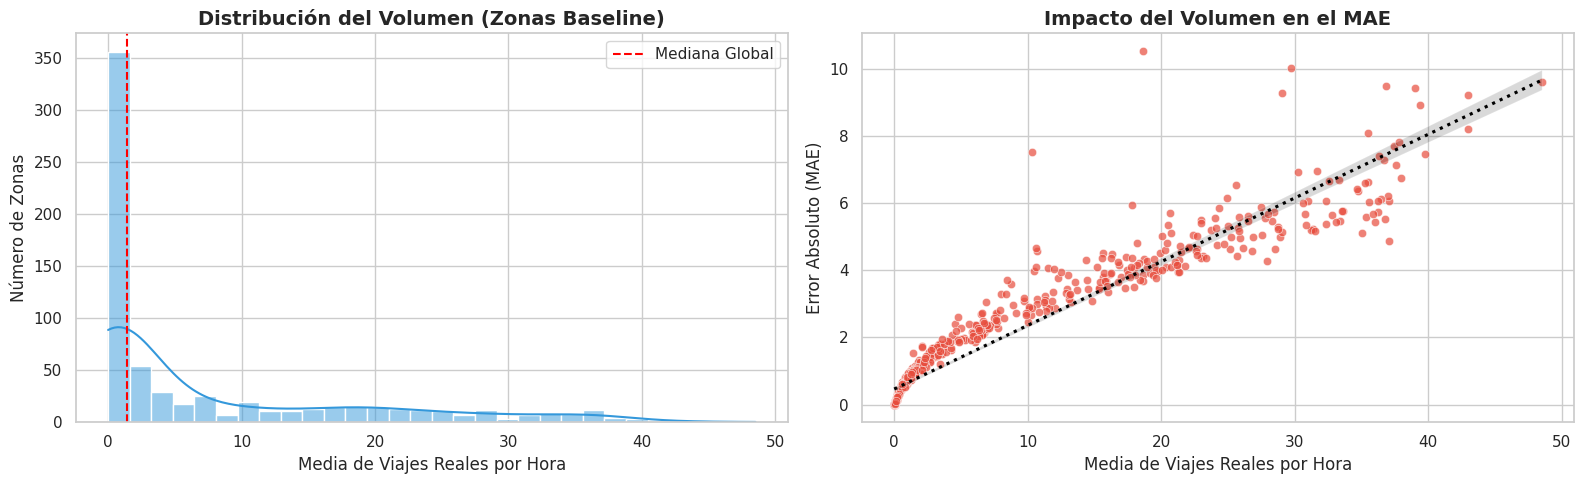


📋 Resumen Estadístico de las Zonas Baseline:
       Demanda_Media     MAE  Error_Porcentual_%
count         693.00  693.00              693.00
mean            7.68    1.92               38.11
std            10.96    2.18               23.06
min             0.00    0.00                0.16
25%             0.06    0.06               20.29
50%             1.45    1.00               31.46
75%            12.96    3.48               56.17
max            48.51   10.52              104.96


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from darts.metrics import mae

print("⏳ Recopilando datos y errores EXACTOS del modelo BASELINE...")

# 1. Sacamos las predicciones del modelo Baseline
preds_tf_hist_base = modelo_baseline.historical_forecasts(
    series=val_baseline["targets"],
    past_covariates=val_baseline["past"],
    future_covariates=train_baseline["future"],
    start=72,                   
    forecast_horizon=24,        
    stride=24,                  
    retrain=False,              
    last_points_only=False,     
    num_samples=200             
)

# 2. Invertimos la realidad y calculamos los errores zona por zona
val_real_base = pipe_high.inverse_transform(val_baseline["targets"])
errores_zona_base = []
demanda_media_zonas = []

for i, lista_dias_zona in enumerate(preds_tf_hist_base):
    # Calcular MAE
    errores_dias = []
    for dia_pred_tf in lista_dias_zona:
        dia_pred_real = pipe_high.inverse_transform(dia_pred_tf)
        pred_p50 = dia_pred_real.quantile(0.50)
        actual_real = val_real_base[i].slice_intersect(pred_p50)
        errores_dias.append(mae(actual_real, pred_p50))
    
    mae_zona_total = np.mean(errores_dias)
    errores_zona_base.append(mae_zona_total)
    
    # Calcular volumen medio de la zona (usando la realidad invertida)
    media_viajes = val_real_base[i].values().flatten().mean()
    demanda_media_zonas.append(media_viajes)

# 3. Construimos el DataFrame para el análisis
df_analisis_base = pd.DataFrame({
    'Demanda_Media': demanda_media_zonas,
    'MAE': errores_zona_base
})

# Añadimos un pequeño epsilon (0.1) para evitar divisiones por cero
df_analisis_base['Error_Porcentual_%'] = (df_analisis_base['MAE'] / (df_analisis_base['Demanda_Media'] + 0.1)) * 100

# ==========================================
# VISUALIZACIÓN
# ==========================================
print("📊 Generando gráficos...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- GRÁFICO 1: Distribución de la Demanda ---
sns.histplot(data=df_analisis_base, x='Demanda_Media', bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Distribución del Volumen (Zonas Baseline)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Media de Viajes Reales por Hora')
axes[0].set_ylabel('Número de Zonas')
axes[0].axvline(df_analisis_base['Demanda_Media'].median(), color='red', linestyle='--', label='Mediana Global')
axes[0].legend()

# --- GRÁFICO 2: ¿Afecta el volumen al MAE? ---
sns.scatterplot(data=df_analisis_base, x='Demanda_Media', y='MAE', alpha=0.7, color='#e74c3c', ax=axes[1])
sns.regplot(data=df_analisis_base, x='Demanda_Media', y='MAE', scatter=False, color='black', line_kws={'linestyle':':'}, ax=axes[1])

axes[1].set_title('Impacto del Volumen en el MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Media de Viajes Reales por Hora')
axes[1].set_ylabel('Error Absoluto (MAE)')

plt.tight_layout()
plt.show()

# ==========================================
# RESUMEN ESTADÍSTICO
# ==========================================
print("\n📋 Resumen Estadístico de las Zonas Baseline:")
print(df_analisis_base[['Demanda_Media', 'MAE', 'Error_Porcentual_%']].describe().round(2))

La sospecha es cierta, el modelo falla porque no aprende distrubuciones, solo predice 0. Para solucionarlo podemos usar otra funcion probabilistica, debido a la alta varianza de los datos, usaremos la Distribución Binomial Negativa o una Poisson, que precisamente tiende a predicir numeros bajos y en ocasiones excepcionales algo mas.
Entreemos el modelo de nuevo y vemaos que tal mejora

Lo unico que hay que hacer primero es deshacer el log1p, ya que la binomial es una distribucion entera

In [21]:

#Modificamos la función de preparación 
CORTE = pd.Timestamp("2025-11-20 00:00:00") 
VENTANA_TRAIN = 96 # 72h input + 24h output
VENTANA_VAL = 168   # Evaluamos solo 1 día para evitar el error de horizonte lejano

def preparar_entrenamiento(targets, past, future, nombre_segmento):
    """
    Filtra, divide y aplica las transformaciones.
    Construye las series de validación con el contexto histórico necesario (72h).
    """
    if not targets:
        return {}, {}, None, None

    print(f"\nDividiendo datos y aplicando pipelines para: {nombre_segmento}...")

    INPUT_CHUNK = 72
    OUTPUT_CHUNK = 24

    tr_tgt, val_tgt = [], []
    tr_pst, val_pst = [], []
    tr_fut, val_fut = [], []

    zonas_descartadas = 0

    for tgt, pst, fut in zip(targets, past, future):
        
        # 1. ESCUDO: ¿Hay datos a ambos lados del corte?
        if tgt.start_time() < CORTE and (tgt.end_time() - CORTE).days >= 1:
            
            # Cortamos por la fecha exacta SOLO para ver la longitud del train
            tr_t_temp, ts_t_temp = tgt.split_before(CORTE)
            
            # 2. ESCUDO: ¿Tiene el tamaño mínimo? (Train > 72, Val > 24)
            if len(tr_t_temp) >= INPUT_CHUNK and len(ts_t_temp) >= OUTPUT_CHUNK:
                
                # Obtenemos el índice numérico exacto del corte
                idx = len(tr_t_temp) 
                
                # TRAIN: Todo desde el inicio hasta el corte (como siempre)
                tr_tgt.append(tgt[:idx])
                tr_pst.append(pst[:idx])
                
                # VALIDACIÓN: 72h antes del corte + 24h después del corte = 96h
        
                val_tgt.append(tgt[idx - INPUT_CHUNK : idx + VENTANA_VAL])
                val_pst.append(pst[idx - INPUT_CHUNK : idx + VENTANA_VAL])

                #El futuro es todo
                tr_fut.append(fut) 
                val_fut.append(fut)
                
                
            else:
                zonas_descartadas += 1
        else:
            zonas_descartadas += 1

    print(f"{nombre_segmento}: {len(tr_tgt)} series válidas listas. Descartadas: {zonas_descartadas}")

    if not tr_tgt:
        return {}, {}, None,None

    # ==========================================
    # PIPELINES (Log1p)
    # ==========================================
    target_pipeline = Pipeline([InvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)])
    past_pipeline = Pipeline([Mapper(fn=np.log1p)])

    if nombre_segmento != "BASELINE":
        print(f"Aplicando transformaciones logarítmicas a {nombre_segmento}...")
        dict_train = {
            "targets": target_pipeline.fit_transform(tr_tgt),
            "past": past_pipeline.fit_transform(tr_pst),
            "future": tr_fut 
        }
        
        dict_val = {
            "targets_real": val_tgt, 
            "targets": target_pipeline.transform(val_tgt),
            "past": past_pipeline.transform(val_pst),
            "future": val_fut
        }
    else:
        print(f"Aplicando transformaciones logarítmicas SOLO a los covariables de {nombre_segmento}...")
        dict_train = {
            "targets": tr_tgt, 
            "past": past_pipeline.fit_transform(tr_pst),
            "future": tr_fut 
        }
        
        dict_val = {
            "targets_real": val_tgt, 
            "targets": val_tgt, 
            "past": past_pipeline.transform(val_pst),
            "future": val_fut
        }
    return dict_train, dict_val, target_pipeline, past_pipeline

# ==========================================
# EJECUTAR PARA NUESTROS SEGMENTOS
# ==========================================
train_high, val_high, pipe_high, pipe_past_high = preparar_entrenamiento(targets_high, past_high, future_high, "ALTA Demanda")
train_mid, val_mid, pipe_mid, pipe_past_mid = preparar_entrenamiento(targets_mid, past_mid, future_mid, "MEDIA Demanda")
train_baseline, val_baseline, pipe_base, pipe_past_base = preparar_entrenamiento(targets_baseline, past_baseline, future_baseline, "BASELINE")

print("\n¡Todos los datos están listos y empaquetados para entrenar!")


Dividiendo datos y aplicando pipelines para: ALTA Demanda...
ALTA Demanda: 80 series válidas listas. Descartadas: 0
Aplicando transformaciones logarítmicas a ALTA Demanda...

Dividiendo datos y aplicando pipelines para: MEDIA Demanda...
MEDIA Demanda: 220 series válidas listas. Descartadas: 0
Aplicando transformaciones logarítmicas a MEDIA Demanda...

Dividiendo datos y aplicando pipelines para: BASELINE...
BASELINE: 693 series válidas listas. Descartadas: 46
Aplicando transformaciones logarítmicas SOLO a los covariables de BASELINE...

¡Todos los datos están listos y empaquetados para entrenar!


Además ahora no necesitamos configuraciones muy demandantes

In [ ]:

from torch.nn import HuberLoss
from darts.utils.likelihood_models import PoissonLikelihood


torch.set_float32_matmul_precision('medium') 
# ==========================================
# ESPECIALISTA 2: Media DEMANDA (El Modelo medio)
# ==========================================
if train_baseline["targets"]:
    print("\n" + "="*50)
    print("ENTRENANDO ESPECIALISTA: Media DEMANDA")
    print("="*50)

    detenedor_baseline = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=0.001,
        mode="min",
    )

    modelo_baseline = TiDEModel(
        input_chunk_length=72,   
        output_chunk_length=24,  
        
        # Arquitectura pesada para absorber picos gigantes
        num_encoder_layers=1,  
        num_decoder_layers=1,  
        decoder_output_dim=16,
        hidden_size=128,         
        dropout=0.15, 
        
        use_static_covariates=True, 
        use_reversible_instance_norm=True, 

        batch_size=1024,          
        n_epochs=30,              
        optimizer_kwargs={"lr": 1e-3}, 
        random_state=42,         
        
        likelihood=PoissonLikelihood(),
        
        pl_trainer_kwargs={
            "accelerator": "gpu",
            "devices": -1,
            "gradient_clip_val": 0.5, 
            "callbacks": [detenedor_baseline],
            "precision": "32-true"
        },
        
        # MLOps
        work_dir="darts_models", 
        model_name="tide_nyc_baseline_v5",        
        save_checkpoints=True,            
        force_reset=True,   
    )

    modelo_baseline.fit(
        series=train_baseline["targets"],              
        past_covariates=train_baseline["past"],        
        future_covariates=train_baseline["future"],        
        val_series=val_baseline["targets"],            
        val_past_covariates=val_baseline["past"],      
        val_future_covariates=val_baseline["future"],      
        dataloader_kwargs={"num_workers": 8},
        verbose=True,                        
    )

In [31]:
from darts.metrics import mae
import numpy as np
modelo_baseline = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_baseline_v5", 
    work_dir="darts_models",
    best=True,
    weights_only=False
)

VENTANA_VAL = 168 
print("📊 Calculando MAE de Validación y MAE Global...\n")

segmentos = [
    ("BASELINE", modelo_baseline, train_baseline, val_baseline),
    ("MEDIA Demanda", modelo_mid, train_mid, val_mid),
    ("ALTA Demanda", modelo_high, train_high, val_high)
]

# El "saco" donde guardaremos los errores de todas las zonas juntas
errores_globales = []

for nombre, modelo, train_data, val_data in segmentos:
    print(f"⏳ Evaluando {nombre}...")
    
    preds_tf_hist = modelo.historical_forecasts(
        series=val_data["targets"],
        past_covariates=val_data["past"],
        future_covariates=train_data["future"],
        start=72,                   
        forecast_horizon=24,        
        stride=24,                  
        retrain=False,              
        last_points_only=False,     
        num_samples=200             
    )

    val_real = val_data["targets_real"]
    errores_zona = []
    
    for i, lista_dias_zona in enumerate(preds_tf_hist):
        errores_dias = [] # Guardaremos el error de cada uno de los 7 días
        
        # 🔥 EL TRUCO: Evaluamos cada bloque de 24h por separado (Cero .append)
        for dia_pred_tf in lista_dias_zona:
            # Invertimos el logaritmo solo de este día
            if nombre != "BASELINE":
                dia_pred_real = pipe_high.inverse_transform(dia_pred_tf)
            else:
                dia_pred_real = dia_pred_tf
            pred_p50 = dia_pred_real.quantile(0.50)
            
            # Buscamos la realidad exacta para este día
            actual_real = val_real[i].slice_intersect(pred_p50)
            
            # Calculamos el error de este día concreto
            error_dia = mae(actual_real, pred_p50)
            errores_dias.append(error_dia)
            
        # La media de los 7 días es el MAE total de esta zona
        mae_zona_total = np.mean(errores_dias)
        
        errores_zona.append(mae_zona_total)
        errores_globales.append(mae_zona_total)
        
    mae_promedio = np.mean(errores_zona)
    print(f"   🎯 MAE [{nombre}]: {mae_promedio:.2f} viajes/hora")

# ==========================================
# 🌍 CÁLCULO DEL MAE GLOBAL
# ==========================================
mae_total_real = np.mean(errores_globales)

print("\n" + "="*40)
print(f"🏆 MAE GLOBAL DEL SISTEMA: {mae_total_real:.2f} viajes/hora")
print("="*40)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


📊 Calculando MAE de Validación y MAE Global...

⏳ Evaluando BASELINE...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   🎯 MAE [BASELINE]: 1.90 viajes/hora
⏳ Evaluando MEDIA Demanda...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


   🎯 MAE [MEDIA Demanda]: 10.18 viajes/hora
⏳ Evaluando ALTA Demanda...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


   🎯 MAE [ALTA Demanda]: 19.83 viajes/hora

🏆 MAE GLOBAL DEL SISTEMA: 5.18 viajes/hora


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


⏳ Recopilando datos y errores EXACTOS del modelo BASELINE...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


📊 Generando gráficos...


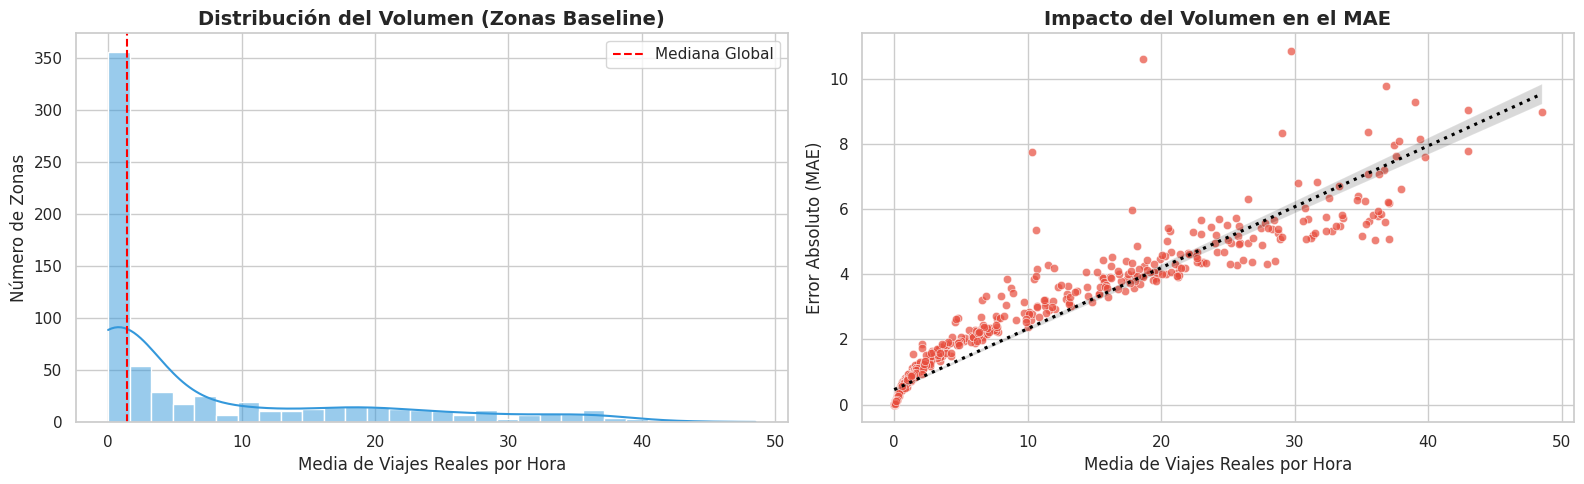


📋 Resumen Estadístico de las Zonas Baseline:
       Demanda_Media     MAE  Error_Porcentual_%
count         693.00  693.00              693.00
mean            7.68    1.90               37.10
std            10.96    2.16               22.95
min             0.00    0.00                0.00
25%             0.06    0.06               19.70
50%             1.45    0.96               30.21
75%            12.96    3.49               53.91
max            48.51   10.86              105.02


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from darts.metrics import mae

print("⏳ Recopilando datos y errores EXACTOS del modelo BASELINE...")

# 1. Sacamos las predicciones del modelo Baseline
preds_tf_hist_base = modelo_baseline.historical_forecasts(
    series=val_baseline["targets"],
    past_covariates=val_baseline["past"],
    future_covariates=train_baseline["future"],
    start=72,                   
    forecast_horizon=24,        
    stride=24,                  
    retrain=False,              
    last_points_only=False,     
    num_samples=200             
)

# 2. Invertimos la realidad y calculamos los errores zona por zona
val_real_base = val_baseline["targets_real"]
errores_zona_base = []
demanda_media_zonas = []

for i, lista_dias_zona in enumerate(preds_tf_hist_base):
    # Calcular MAE
    errores_dias = []
    for dia_pred_tf in lista_dias_zona:
        dia_pred_real = dia_pred_tf
        pred_p50 = dia_pred_real.quantile(0.50)
        actual_real = val_real_base[i].slice_intersect(pred_p50)
        errores_dias.append(mae(actual_real, pred_p50))
    
    mae_zona_total = np.mean(errores_dias)
    errores_zona_base.append(mae_zona_total)
    
    # Calcular volumen medio de la zona (usando la realidad invertida)
    media_viajes = val_real_base[i].values().flatten().mean()
    demanda_media_zonas.append(media_viajes)

# 3. Construimos el DataFrame para el análisis
df_analisis_base = pd.DataFrame({
    'Demanda_Media': demanda_media_zonas,
    'MAE': errores_zona_base
})

# Añadimos un pequeño epsilon (0.1) para evitar divisiones por cero
df_analisis_base['Error_Porcentual_%'] = (df_analisis_base['MAE'] / (df_analisis_base['Demanda_Media'] + 0.1)) * 100

# ==========================================
# VISUALIZACIÓN
# ==========================================
print("📊 Generando gráficos...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- GRÁFICO 1: Distribución de la Demanda ---
sns.histplot(data=df_analisis_base, x='Demanda_Media', bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Distribución del Volumen (Zonas Baseline)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Media de Viajes Reales por Hora')
axes[0].set_ylabel('Número de Zonas')
axes[0].axvline(df_analisis_base['Demanda_Media'].median(), color='red', linestyle='--', label='Mediana Global')
axes[0].legend()

# --- GRÁFICO 2: ¿Afecta el volumen al MAE? ---
sns.scatterplot(data=df_analisis_base, x='Demanda_Media', y='MAE', alpha=0.7, color='#e74c3c', ax=axes[1])
sns.regplot(data=df_analisis_base, x='Demanda_Media', y='MAE', scatter=False, color='black', line_kws={'linestyle':':'}, ax=axes[1])

axes[1].set_title('Impacto del Volumen en el MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Media de Viajes Reales por Hora')
axes[1].set_ylabel('Error Absoluto (MAE)')

plt.tight_layout()
plt.show()

# ==========================================
# RESUMEN ESTADÍSTICO
# ==========================================
print("\n📋 Resumen Estadístico de las Zonas Baseline:")
print(df_analisis_base[['Demanda_Media', 'MAE', 'Error_Porcentual_%']].describe().round(2))

no mejora, pero si nos damos cuenta, el problema es que hay mucha media 0, entonces en verdad puedo aislar los casos con media 0. Rehagamos el kmeans y reentrenemos los modelos, para demostrar que esto va mejor simplemente entrenare el cluster bajo y veamos si va mejor, en caso de que si, la idea será reentrenar con todos los datos, incluidos los que usare en test. Además antes el kmeans era solo de las medias, lo que solo evalua la escala del problema, pero no tenemos en cuenta la varianza de los datos, por tanto ahora clasificaremos los clusteres usaremos:
1. El estándar de Volatilidad: El Coeficiente de Variación (CV)

En la teoría estadística, la volatilidad no se mide con el máximo, se mide con el Coeficiente de Variación.
CV=μσ​

(Donde σ es la desviación típica y μ es la media).

    "Según el marco teórico de Syntetos-Boylan (2005) para demanda intermitente, la categorización de una serie temporal depende de su intervalo de demanda y su CV2. Sustituimos el agrupamiento por volumen bruto por el CV para garantizar que el modelo de Deep Learning (TiDE) reciba series con niveles de ruido o dispersión similares, estabilizando la convergencia del gradiente durante el entrenamiento."


2. El paradigma FFORMA (Meta-Learning)

Defensa:

    "Nuestra arquitectura de 'Router + Especialistas' sigue los principios del algoritmo FFORMA (Ganador de la competición global M4 Forecasting), que demostró empíricamente que agrupar series temporales mediante meta-características (escala, estacionalidad y volatilidad) para enrutarlas a distintos modelos supera a cualquier modelo único y masivo."

Primero veamos como se distribuyen estas metricas por si fuese necesario hacer más de 3 clusters

📊 Generando Panel de Distribuciones de Meta-Características...


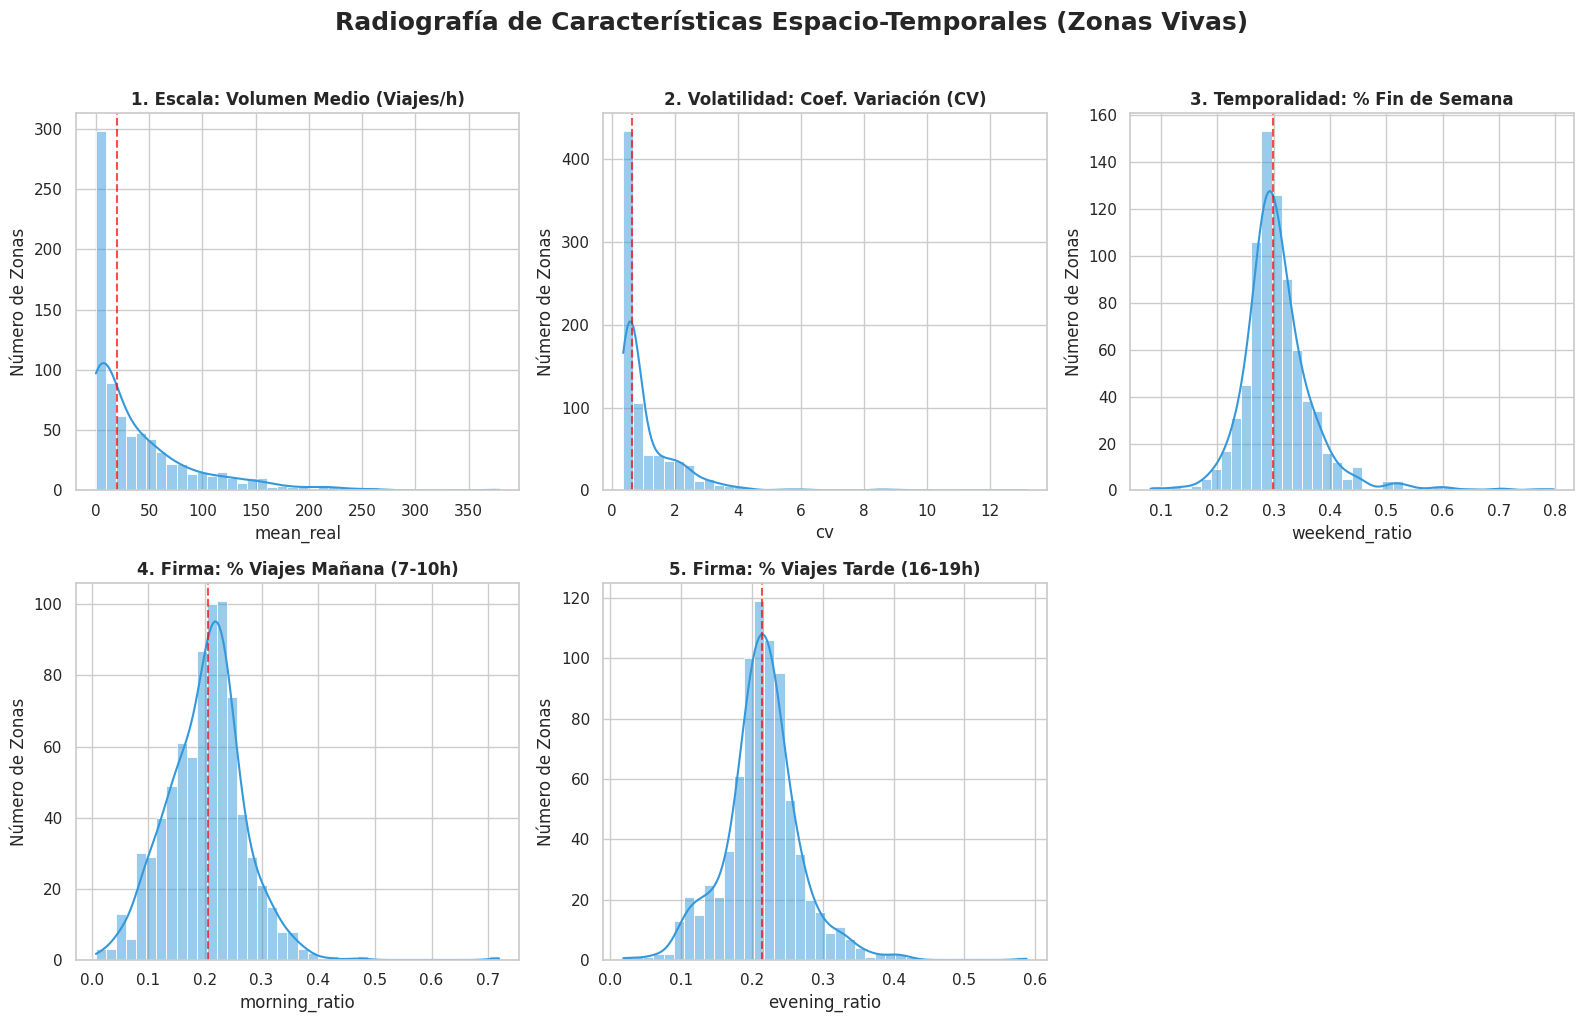

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
fecha_min = df_pd['timestamp'].min()
fecha_max = df_pd['timestamp'].max()
horas_totales = max(1, round((fecha_max - fecha_min).total_seconds() / 3600))

df_pd['is_weekend'] = df_pd['timestamp'].dt.dayofweek >= 5
df_pd['is_morning_peak'] = df_pd['timestamp'].dt.hour.between(7, 10)  # Commuters yendo a trabajar
df_pd['is_evening_peak'] = df_pd['timestamp'].dt.hour.between(16, 19) # Commuters volviendo / Ocio

# 2. Agrupación matemática estricta
agrupado = df_pd.groupby('Series_ID').agg(
    total_demand=('demand', 'sum'),
    std_demand=('demand', 'std'), # 🔥 Clave para el Coeficiente de Variación
    weekend_demand=('demand', lambda x: x[df_pd.loc[x.index, 'is_weekend']].sum()),
    morning_demand=('demand', lambda x: x[df_pd.loc[x.index, 'is_morning_peak']].sum()),
    evening_demand=('demand', lambda x: x[df_pd.loc[x.index, 'is_evening_peak']].sum())
).reset_index()

# 3. Construimos el Feature Space (Las 5 dimensiones para K-Means)
agrupado['mean_real'] = agrupado['total_demand'] / horas_totales

# Dimensión 2: Coeficiente de Variación (Volatilidad estadística real: sigma / mu)
agrupado['cv'] = agrupado['std_demand'] / (agrupado['mean_real'] + 0.0001)

# Dimensiones 3, 4 y 5: Firmas Temporales
agrupado['weekend_ratio'] = agrupado['weekend_demand'] / (agrupado['total_demand'] + 0.0001)
agrupado['morning_ratio'] = agrupado['morning_demand'] / (agrupado['total_demand'] + 0.0001)
agrupado['evening_ratio'] = agrupado['evening_demand'] / (agrupado['total_demand'] + 0.0001)

# Limpiamos NaNs por si alguna serie tuvo 0 varianza (constante)
agrupado.fillna({'cv': 0}, inplace=True)

# 4. FILTRO BASELINE (Zonas muertas < 0.1 viajes/hora)
UMBRAL_MUERTO = 0.1 
zonas_muertas = agrupado[agrupado['mean_real'] < UMBRAL_MUERTO].copy()
zonas_vivas = agrupado[agrupado['mean_real'] >= UMBRAL_MUERTO].copy()
zonas_muertas['segmento'] = 'BASELINE'

print("📊 Generando Panel de Distribuciones de Meta-Características...")

# Las 5 dimensiones que hemos creado
columnas_plot = ['mean_real', 'cv', 'weekend_ratio', 'morning_ratio', 'evening_ratio']
titulos = [
    '1. Escala: Volumen Medio (Viajes/h)', 
    '2. Volatilidad: Coef. Variación (CV)',
    '3. Temporalidad: % Fin de Semana', 
    '4. Firma: % Viajes Mañana (7-10h)', 
    '5. Firma: % Viajes Tarde (16-19h)'
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_plot):
    # Usamos kde=True para ver la forma de la curva claramente
    sns.histplot(data=zonas_vivas, x=col, kde=True, ax=axes[i], color='#3498db', bins=40)
    axes[i].set_title(titulos[i], fontweight='bold')
    axes[i].set_ylabel('Número de Zonas')
    
    # Marcamos la mediana con una línea roja para tener referencia
    mediana = zonas_vivas[col].median()
    axes[i].axvline(mediana, color='red', linestyle='--', alpha=0.7)

# Borramos el 6º gráfico que nos sobra en la cuadrícula 2x3
fig.delaxes(axes[5])

plt.suptitle("Radiografía de Características Espacio-Temporales (Zonas Vivas)", fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder
from sklearn.preprocessing import StandardScaler  as SklearnStandardScaler 
from sklearn.cluster import KMeans
from darts import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries

df_pd = pd.read_parquet("../data/data_darts.parquet")

# Es vital que los datos estén ordenados temporalmente dentro de cada grupo
df_pd = df_pd.sort_values(by=["Series_ID", "timestamp"])

fecha_limite = df_pd['timestamp'].max() - pd.DateOffset(years=3)
df_pd = df_pd[df_pd['timestamp'] >= fecha_limite].copy()

# =============================================
# PREPROCESAMIENTO DE VARIABLES
# =============================================
# LATITUD Y LONGITUD (Escalado espacial)
scaler_espacial = MinMaxScaler()
cols_geo = ["Latitude", "Longitude"]
df_pd[cols_geo] = scaler_espacial.fit_transform(df_pd[cols_geo])
df_pd[cols_geo] = df_pd[cols_geo].astype("float32")

# VARIABLES NUMÉRICAS (Float32)
cols_numericas = ["demand", "avg_distance", "avg_amount"]
df_pd[cols_numericas] = df_pd[cols_numericas].astype("float32")

print("Aplicando One-Hot Encoding a VendorID...")
encoder_vendor = SklearnOneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
dummies_array = encoder_vendor.fit_transform(df_pd[['VendorID']])
nombres_dummies = encoder_vendor.get_feature_names_out(['VendorID'])
df_pd[nombres_dummies] = dummies_array
df_pd["VendorID"] = df_pd["VendorID"].astype("float32") # Mantenemos el original para Darts

columnas_estaticas = list(nombres_dummies) + ["Latitude", "Longitude"]
df_pd[columnas_estaticas] = df_pd[columnas_estaticas].astype("float32")
print(f"Variables estáticas que verá el modelo: {columnas_estaticas}")



print("\nIniciando Segmentación Basada en Características (Temporal Signatures, CV & ADI)...")

# 1. Preparación de franjas horarias estrictas (Firmas Temporales)
fecha_min = df_pd['timestamp'].min()
fecha_max = df_pd['timestamp'].max()
horas_totales = max(1, round((fecha_max - fecha_min).total_seconds() / 3600))

df_pd['is_weekend'] = df_pd['timestamp'].dt.dayofweek >= 5


# 1. Agrupación y cálculo del ADI
agrupado = df_pd.groupby('Series_ID').agg(
    total_demand=('demand', 'sum'),
    std_demand=('demand', 'std'),
    weekend_demand=('demand', lambda x: x[df_pd.loc[x.index, 'is_weekend']].sum()),
    horas_con_actividad=('demand', 'count') 
).reset_index()

agrupado['mean_real'] = agrupado['total_demand'] / horas_totales
agrupado['cv'] = agrupado['std_demand'] / (agrupado['mean_real'] + 0.0001)

# 🎯 CORRECCIÓN: Volvemos a calcular el weekend_ratio
agrupado['weekend_ratio'] = agrupado['weekend_demand'] / (agrupado['total_demand'] + 0.0001)

# 🎯 EL ÍNDICE ADI (Average Demand Interval)
# Mide cuántas horas pasan entre viajes. Si horas_con_actividad es 0, ponemos infinito.
agrupado['adi'] = np.where(agrupado['horas_con_actividad'] > 0, 
                           horas_totales / agrupado['horas_con_actividad'], 
                           np.inf)

agrupado['cv2'] = agrupado['cv'] ** 2

# Limpiamos NaNs por si alguna serie tuvo 0 varianza
agrupado.fillna({'cv': 0, 'cv2': 0}, inplace=True)

# 2. FILTRO BASELINE MATEMÁTICO (Basado en Syntetos-Boylan)
UMBRAL_ADI = 1.5 
UMBRAL_CV2 = 0.5

# Es BASELINE si es "Lumpy" extremo (Muy intermitente Y muy errática)
mask_lumpy = ((agrupado['adi'] > UMBRAL_ADI) & (agrupado['cv2'] > UMBRAL_CV2)) | (agrupado['mean_real'] < 0.5)

zonas_muertas = agrupado[mask_lumpy].copy()
zonas_vivas = agrupado[~mask_lumpy].copy()
zonas_muertas['segmento'] = 'BASELINE'

print(f"   - Zonas enviadas a BASELINE (Ruido Matemático / Lumpy): {len(zonas_muertas)}")

# =========================================================
#  MULTIDIMENSIONAL 
# =========================================================
# Pasamos las 3 variables maestras (ahora sí existe weekend_ratio)
columnas_features = ['mean_real', 'cv', 'weekend_ratio']
features = zonas_vivas[columnas_features].values

# 🎯 CORRECCIÓN: Usamos StandardScaler correctamente
scaler_kmeans = SklearnStandardScaler()
features_scaled = scaler_kmeans.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
zonas_vivas['cluster_id'] = kmeans.fit_predict(features_scaled)

# Ordenamos guiándonos por el volumen (mean_real) para mantener la jerarquía semántica
centros_no_escalados = scaler_kmeans.inverse_transform(kmeans.cluster_centers_)
orden_clusters = np.argsort(centros_no_escalados[:, 0])

mapa_clusters = {
    orden_clusters[0]: 'LOW',  
    orden_clusters[1]: 'MID', 
    orden_clusters[2]: 'HIGH'      
}
zonas_vivas['segmento'] = zonas_vivas['cluster_id'].map(mapa_clusters)

# Unimos todo
todas_las_zonas = pd.concat([zonas_muertas, zonas_vivas])

print("\n🎯 RESULTADOS DEL CLUSTERING FINAL (Defensa Académica):")
for seg in ['BASELINE', 'LOW', 'MID', 'HIGH']:
    df_seg = todas_las_zonas[todas_las_zonas['segmento'] == seg]
    if not df_seg.empty:
        print(f"   - {seg}: {len(df_seg)} zonas | Media: {df_seg['mean_real'].mean():.1f} | CV: {df_seg['cv'].mean():.1f} | ADI: {df_seg['adi'].mean():.2f}")
        
# 5. Crear los DataFrames físicos
df_pd = df_pd.merge(todas_las_zonas[['Series_ID', 'segmento']], on='Series_ID', how='left')

df_baseline = df_pd[df_pd['segmento'] == 'BASELINE'].copy() 
df_low      = df_pd[df_pd['segmento'] == 'LOW'].copy()
df_medias   = df_pd[df_pd['segmento'] == 'MID'].copy()
df_altas    = df_pd[df_pd['segmento'] == 'HIGH'].copy()

# =============================================
# CONVERSIÓN A DARTS TIMESERIES
# =============================================
col_tiempo = "timestamp"
col_grupo = ["PULocationID", "VendorID"]

# CREAMOS EL CALENDARIO MAESTRO
print("\nGenerando Calendario Maestro de Covariables Futuras...")
HORAS_EXTRA = 48
inicio_global = df_pd['timestamp'].min()
fin_global = df_pd['timestamp'].max() + pd.Timedelta(hours=HORAS_EXTRA)

indice_global = pd.date_range(start=inicio_global, end=fin_global, freq='h')
cov_hora_global = datetime_attribute_timeseries(indice_global, attribute="hour", cyclic=True)
cov_dia_global = datetime_attribute_timeseries(indice_global, attribute="dayofweek", cyclic=True)
calendario_maestro = cov_hora_global.stack(cov_dia_global).astype("float32")

def preparar_dataset_darts(df_segmento, nombre_segmento):
    """Convierte un DataFrame de Pandas en las 3 listas de TimeSeries para TiDE"""
    if df_segmento.empty:
        return [], [], []
    
    targets = TimeSeries.from_group_dataframe(
        df_segmento, group_cols=col_grupo, time_col=col_tiempo, value_cols="demand",
        static_cols=columnas_estaticas, fill_missing_dates=True, freq='h', fillna_value=0           
    )
    
    past_covs = TimeSeries.from_group_dataframe(
        df_segmento, group_cols=col_grupo, time_col=col_tiempo, value_cols=["avg_distance", "avg_amount"],
        fill_missing_dates=True, freq='h', fillna_value=0           
    )
    
    future_covs = [calendario_maestro] * len(targets)
    return targets, past_covs, future_covs

print(f"\nPreparando tensores para TiDE...")
# Nota: Ignoramos df_baseline intencionadamente
targets_low, past_low, future_low = preparar_dataset_darts(df_low, "Baja Demanda")
targets_mid, past_mid, future_mid = preparar_dataset_darts(df_medias, "Media Demanda")
targets_high, past_high, future_high = preparar_dataset_darts(df_altas, "Alta Demanda")

print("✅ Pipeline de datos completado.")

Aplicando One-Hot Encoding a VendorID...
Variables estáticas que verá el modelo: ['VendorID_1', 'VendorID_2', 'VendorID_3', 'Latitude', 'Longitude']

Iniciando Segmentación Basada en Características (Temporal Signatures, CV & ADI)...
   - Zonas enviadas a BASELINE (Ruido Matemático / Lumpy): 460

🎯 RESULTADOS DEL CLUSTERING FINAL (Defensa Académica):
   - BASELINE: 460 zonas | Media: 0.4 | CV: 21.0 | ADI: 490.88
   - LOW: 61 zonas | Media: 23.0 | CV: 1.2 | ADI: 1.15
   - MID: 400 zonas | Media: 33.5 | CV: 0.6 | ADI: 1.02
   - HIGH: 118 zonas | Media: 144.1 | CV: 0.6 | ADI: 1.00

Generando Calendario Maestro de Covariables Futuras...

Preparando tensores para TiDE...
✅ Pipeline de datos completado.


Veamos si la distrucion ahora tiene sentido

📊 Generando radiografía del nuevo segmento LOW...


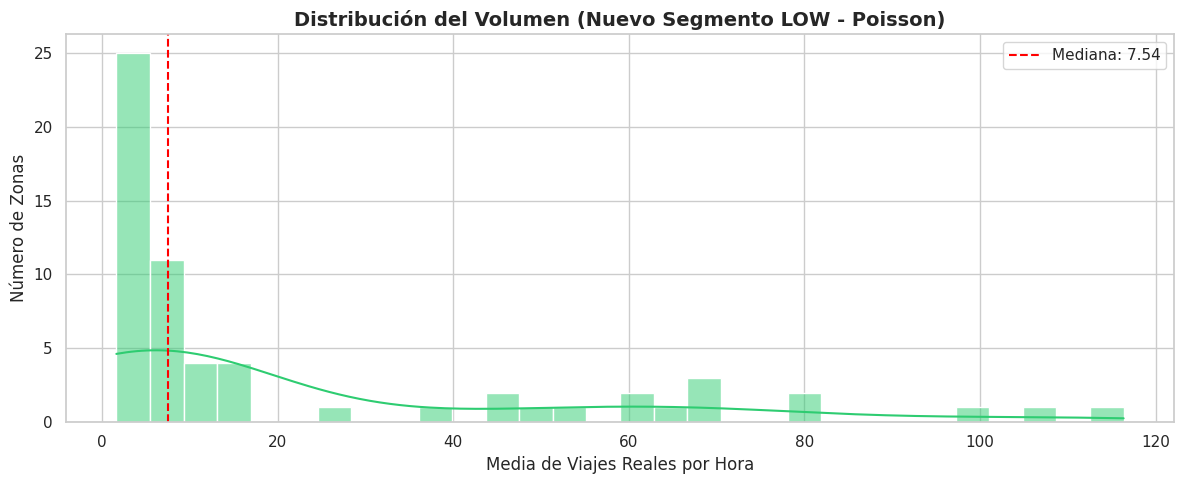


📋 Resumen Estadístico de las Zonas LOW:
count     61.000
mean      23.038
std       30.362
min        1.627
25%        3.815
50%        7.542
75%       39.364
max      116.356
Name: mean_real, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generando radiografía del nuevo segmento LOW...")

# 1. Filtramos exclusivamente las zonas que pasaron el corte (LOW)
df_low_plot = todas_las_zonas[todas_las_zonas['segmento'] == 'LOW'].copy()

# 2. Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

sns.histplot(data=df_low_plot, x='mean_real', bins=30, kde=True, color='#2ecc71')
plt.title('Distribución del Volumen (Nuevo Segmento LOW - Poisson)', fontsize=14, fontweight='bold')
plt.xlabel('Media de Viajes Reales por Hora')
plt.ylabel('Número de Zonas')
plt.axvline(df_low_plot['mean_real'].median(), color='red', linestyle='--', label=f"Mediana: {df_low_plot['mean_real'].median():.2f}")
plt.legend()

plt.tight_layout()
plt.show()

# 3. Resumen estadístico
print("\n📋 Resumen Estadístico de las Zonas LOW:")
print(df_low_plot['mean_real'].describe().round(3))

Casi todas las zonas tienen una media de menos de 10 viajes 

In [34]:
from darts.dataprocessing.transformers import InvertibleMapper, Mapper
from darts.dataprocessing.pipeline import Pipeline
import numpy as np
import pandas as pd

# ==========================================
# DIVISIÓN TRAIN/VAL Y TRANSFORMACIÓN (MODULAR)
# ==========================================
CORTE = pd.Timestamp("2025-11-20 00:00:00") 
VENTANA_TRAIN = 96 # 72h input + 24h output
VENTANA_VAL = 168   # Evaluamos solo 1 día para evitar el error de horizonte lejano

def preparar_entrenamiento(targets, past, future, nombre_segmento):
    """
    Filtra, divide y aplica las transformaciones.
    Construye las series de validación con el contexto histórico necesario (72h).
    """
    if not targets:
        return {}, {}, None, None

    print(f"\nDividiendo datos y aplicando pipelines para: {nombre_segmento}...")

    INPUT_CHUNK = 72
    OUTPUT_CHUNK = 24

    tr_tgt, val_tgt = [], []
    tr_pst, val_pst = [], []
    tr_fut, val_fut = [], []

    zonas_descartadas = 0

    for tgt, pst, fut in zip(targets, past, future):
        
        # 1. ESCUDO: ¿Hay datos a ambos lados del corte?
        if tgt.start_time() < CORTE and (tgt.end_time() - CORTE).days >= 1:
            
            # Cortamos por la fecha exacta SOLO para ver la longitud del train
            tr_t_temp, ts_t_temp = tgt.split_before(CORTE)
            
            # 2. ESCUDO: ¿Tiene el tamaño mínimo? (Train > 72, Val > 24)
            if len(tr_t_temp) >= INPUT_CHUNK and len(ts_t_temp) >= OUTPUT_CHUNK:
                
                # Obtenemos el índice numérico exacto del corte
                idx = len(tr_t_temp) 
                
                # TRAIN: Todo desde el inicio hasta el corte (como siempre)
                tr_tgt.append(tgt[:idx])
                tr_pst.append(pst[:idx])
                
                # VALIDACIÓN: 72h antes del corte + 24h después del corte = 96h
        
                val_tgt.append(tgt[idx - INPUT_CHUNK : idx + VENTANA_VAL])
                val_pst.append(pst[idx - INPUT_CHUNK : idx + VENTANA_VAL])

                #El futuro es todo
                tr_fut.append(fut) 
                val_fut.append(fut)
                
                
            else:
                zonas_descartadas += 1
        else:
            zonas_descartadas += 1

    print(f"{nombre_segmento}: {len(tr_tgt)} series válidas listas. Descartadas: {zonas_descartadas}")

    if not tr_tgt:
        return {}, {}, None,None

    # ==========================================
    # PIPELINES (Log1p)
    # ==========================================
    target_pipeline = Pipeline([InvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)])
    past_pipeline = Pipeline([Mapper(fn=np.log1p)])


    dict_train = {
        "targets": target_pipeline.fit_transform(tr_tgt),
        "past": past_pipeline.fit_transform(tr_pst),
        "future": tr_fut 
    }
    
    dict_val = {
        "targets_real": val_tgt, 
        "targets": target_pipeline.transform(val_tgt),
        "past": past_pipeline.transform(val_pst),
        "future": val_fut
    }
    return dict_train, dict_val, target_pipeline, past_pipeline

# ==========================================
# EJECUTAR PARA NUESTROS SEGMENTOS
# ==========================================
train_high, val_high, pipe_high, pipe_past_high = preparar_entrenamiento(targets_high, past_high, future_high, "ALTA")
train_mid, val_mid, pipe_mid, pipe_past_mid = preparar_entrenamiento(targets_mid, past_mid, future_mid, "MEDIA")
train_low, val_low, pipe_low, pipe_past_low = preparar_entrenamiento(targets_low, past_low, future_low, "LOW")

print("\n¡Todos los datos están listos y empaquetados para entrenar!")


Dividiendo datos y aplicando pipelines para: ALTA...
ALTA: 118 series válidas listas. Descartadas: 0

Dividiendo datos y aplicando pipelines para: MEDIA...
MEDIA: 400 series válidas listas. Descartadas: 0

Dividiendo datos y aplicando pipelines para: LOW...
LOW: 61 series válidas listas. Descartadas: 0

¡Todos los datos están listos y empaquetados para entrenar!


In [35]:

from torch.nn import HuberLoss
from darts.utils.likelihood_models import PoissonLikelihood


torch.set_float32_matmul_precision('medium') 
# ==========================================
# ESPECIALISTA 2: Media DEMANDA (El Modelo medio)
# ==========================================
if train_low["targets"]:
    print("\n" + "="*50)
    print("ENTRENANDO ESPECIALISTA: Media DEMANDA")
    print("="*50)

    detenedor_baseline = EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=0.001,
        mode="min",
    )

    modelo_baseline = TiDEModel(
        input_chunk_length=72,   
        output_chunk_length=24,  
        
        # Arquitectura pesada para absorber picos gigantes
        num_encoder_layers=2,  
        num_decoder_layers=2,  
        decoder_output_dim=64,
        hidden_size=128,         
        dropout=0.15, 
        
        use_static_covariates=True, 
        use_reversible_instance_norm=True, 

        batch_size=512,          
        n_epochs=30,              
        optimizer_kwargs={"lr": 1e-3}, 
        random_state=42,         
        
        likelihood=QuantileRegression(quantiles=[0.1,0.5,0.9]),
        
        pl_trainer_kwargs={
            "accelerator": "gpu",
            "devices": -1,
            "gradient_clip_val": 0.3, 
            "callbacks": [detenedor_baseline],
            "precision": "32-true"
        },
        
        # MLOps
        work_dir="darts_models", 
        model_name="tide_nyc_baseline_v5",        
        save_checkpoints=True,            
        force_reset=True,   
    )

    modelo_baseline.fit(
        series=train_low["targets"],              
        past_covariates=train_low["past"],        
        future_covariates=train_low["future"],        
        val_series=val_low["targets"],            
        val_past_covariates=val_low["past"],      
        val_future_covariates=val_low["future"],      
        dataloader_kwargs={"num_workers": 8},
        verbose=True,                        
    )

number of `past_covariates` features is <= `temporal_width_past`, leading to feature expansion.number of covariates: 2, `temporal_width_past=4`.
number of `future_covariates` features is <= `temporal_width_future`, leading to feature expansion.number of covariates: 4, `temporal_width_future=4`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



ENTRENANDO ESPECIALISTA: Media DEMANDA


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1  │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2  │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3  │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4  │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5  │ rin                   │ RINorm           │      2 │ train │     0 │
│ 6  │ past_cov_projection   │ _ResidualBlock   │    912 │ train │     0 │
│ 7  │ future_cov_projection │ _ResidualBlock   │  1.2 K │ train │     0 │
│ 8  │ encoders              │ Sequential       │  258 K │ train │     0 │
│ 9  │ decoders              │ Sequential       │  1.3 M │ train │     0 │
│ 10 │ temporal_decoder      │ _ResidualBlock   │  7.0 K │ train │     0 │
│ 11 │ lookback_skip         │ Linear           │  5.3 K │ train │     0 │
└────┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

In [5]:
zonas_vivas[zonas_vivas['segmento'] == 'LOW']

,Series_ID,total_demand,std_demand,weekend_demand,horas_con_actividad,mean_real,cv,weekend_ratio,adi,cv2,cluster_id,segmento
15,0_114,1796992.0,75.902351,759080.0,26132,68.316299,1.111041,0.422417,1.006582,1.234413,0,LOW
17,0_116,151922.0,6.143663,50913.0,23546,5.775623,1.063705,0.335126,1.117132,1.131467,0,LOW
31,0_129,78080.0,3.566924,28644.0,20187,2.968370,1.201604,0.366855,1.303017,1.443851,0,LOW
33,0_130,71381.0,3.981548,21999.0,18435,2.713694,1.467152,0.308191,1.426851,2.152536,0,LOW
48,0_144,1295366.0,45.030548,536230.0,25669,49.245972,0.914399,0.413960,1.024738,0.836125,0,LOW
...,...,...,...,...,...,...,...,...,...,...,...,...
977,3_43,245911.0,8.999483,90387.0,24126,9.348806,0.962624,0.367560,1.090276,0.926645,0,LOW
992,3_57,42789.0,1.624183,14838.0,19750,1.626711,0.998385,0.346771,1.331848,0.996772,0,LOW
1016,3_79,2614676.0,77.739174,1099266.0,26302,99.402222,0.782066,0.420422,1.000076,0.611627,0,LOW
1018,3_80,1775805.0,56.396992,805445.0,26302,67.510834,0.835376,0.453566,1.000076,0.697852,0,LOW


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

⏳ Recopilando datos y errores EXACTOS del modelo low...
Buscando la serie correspondiente a la Zona 144 y Vendor 0...
✅ Serie encontrada en el índice 30. Generando predicción probabilística...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



🎯 MAE (Zona 144 | Vendor 0): 5.36 viajes/hora


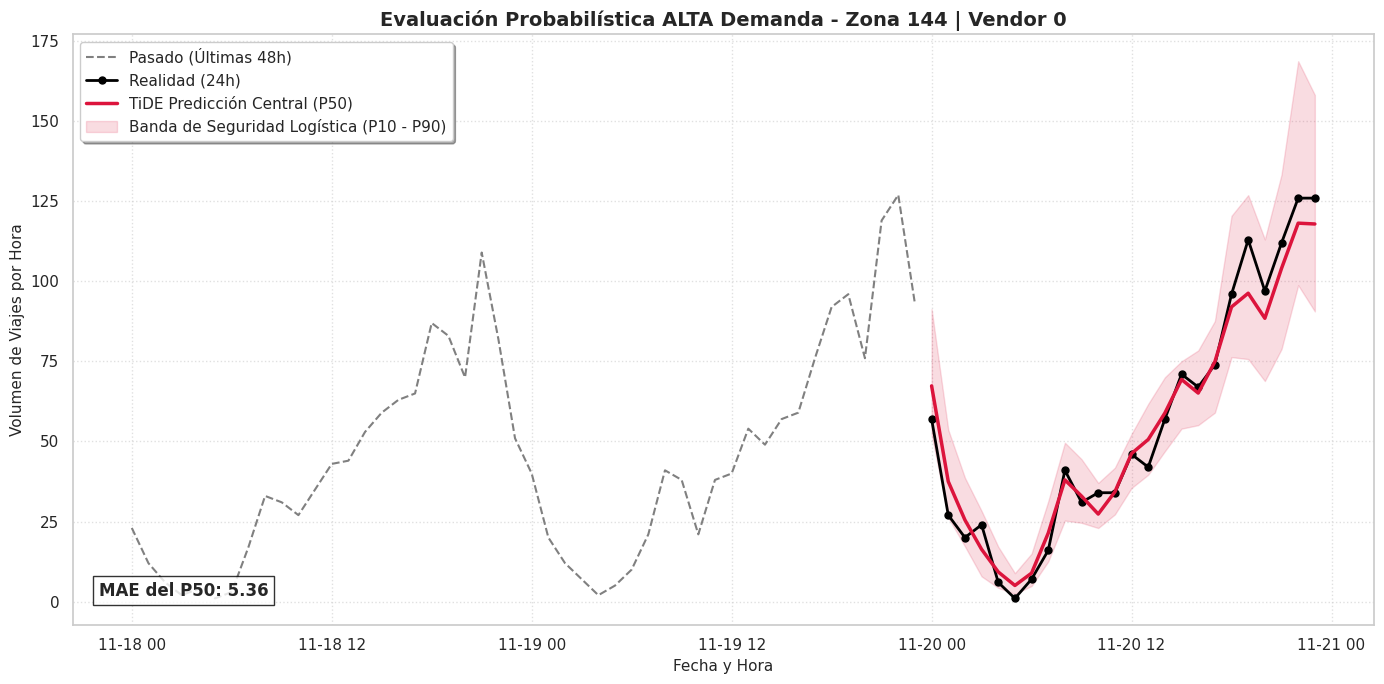

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from darts.metrics import mae

print("⏳ Recopilando datos y errores EXACTOS del modelo low...")
modelo_low = TiDEModel.load_from_checkpoint(
    model_name="tide_nyc_baseline_v5", 
    work_dir="darts_models",
    best=True,
    weights_only=False
)

# --- CONFIGURACIÓN ---
ZONA_Buscada = 144
VENDOR_Buscado = 0
HORIZONTE = 24      # Predicción a 24 horas


print(f"Buscando la serie correspondiente a la Zona {ZONA_Buscada} y Vendor {VENDOR_Buscado}...")

# 2. Encontrar el índice en la lista de ALTA demanda
idx_target = -1
for i, serie in enumerate(train_low["targets"]):
    estaticas = serie.static_covariates
    if estaticas is not None:
        zona_actual = int(estaticas['PULocationID'].iloc[0])
        vendor_actual = int(estaticas['VendorID'].iloc[0])
        
        if zona_actual == ZONA_Buscada and vendor_actual == VENDOR_Buscado:
            idx_target = i
            break

if idx_target == -1:
    print(f"❌ No se encontró la Zona {ZONA_Buscada} con Vendor {VENDOR_Buscado} en el segmento ALTO.")
    print("Intenta buscarla en el segmento MEDIO o low.")
else:
    print(f"✅ Serie encontrada en el índice {idx_target}. Generando predicción probabilística...")

    # 3. Generar Predicción con el modelo
    # 3. Generar Predicción Probabilística con el modelo
    # 🔥 LA LLAVE MAESTRA: Añadimos num_samples para activar las simulaciones estocásticas
    pred_tf = modelo_low.predict(
        n=HORIZONTE,
        series=train_low["targets"][idx_target],
        past_covariates=train_low["past"][idx_target],
        future_covariates=future_low[idx_target],
        num_samples=500 # Darts simulará 200 futuros basados en tus cuantiles
    )

    # 4. Revertir la transformación logarítmicaInvertibleMapper(fn=np.log1p, inverse_fn=np.expm1)
    pred_real = pipe_low.inverse_transform(pred_tf)
    
    # --- MAGIA MLOPS: EXTRACCIÓN DE CUANTILES (NUEVA API) ---
    pred_p10 = pred_real.quantile(0.10) # El escenario pesimista
    pred_p50 = pred_real.quantile(0.50) # El escenario central (Mediana)
    pred_p90 = pred_real.quantile(0.90) # El escenario de alta demanda
    
    # 5. Alinear la realidad
    serie_real_completa = val_low["targets_real"][idx_target]
    actual_real = serie_real_completa.slice_intersect(pred_p50)

    # 6. Calcular MAE usando el escenario central (P50)
    error_mae = mae(actual_real, pred_p50)
    print("\n" + "="*50)
    print(f"🎯 MAE (Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}): {error_mae:.2f} viajes/hora")
    print("="*50)

    # 7. Preparar datos para Visualización (Pasamos a Pandas de forma segura)
    df_p10 = pred_p10.to_dataframe()
    df_p50 = pred_p50.to_dataframe()
    df_p90 = pred_p90.to_dataframe()
    
    df_real = actual_real.to_dataframe()
    df_contexto = pipe_low.inverse_transform(train_low["targets"][idx_target][-48:]).to_dataframe()

    # 8. Visualización MLOps con Bandas de Confianza
    plt.figure(figsize=(14, 7))
    
    # A. Contexto Histórico
    plt.plot(df_contexto.index, df_contexto.iloc[:, 0], label='Pasado (Últimas 48h)', color='gray', linestyle='--')
    
    # B. Realidad Oculta
    plt.plot(df_real.index, df_real.iloc[:, 0], label='Realidad (24h)', color='black', marker='o', linewidth=2, markersize=5)
    
    # C. Predicción Central (P50)
    plt.plot(df_p50.index, df_p50.iloc[:, 0], label='TiDE Predicción Central (P50)', color='crimson', linewidth=2.5)
    
    # D. Bandas de Confianza (P10 - P90)
    # Extraemos los valores como arrays 1D (iloc[:, 0]) para que matplotlib lo dibuje perfecto
    plt.fill_between(
        df_p50.index, 
        df_p10.iloc[:, 0], 
        df_p90.iloc[:, 0], 
        color='crimson', 
        alpha=0.15, 
        label='Banda de Seguridad Logística (P10 - P90)'
    )

    # Estilos
    plt.title(f"Evaluación Probabilística ALTA Demanda - Zona {ZONA_Buscada} | Vendor {VENDOR_Buscado}", fontsize=14, fontweight='bold')
    plt.xlabel("Fecha y Hora", fontsize=11)
    plt.ylabel("Volumen de Viajes por Hora", fontsize=11)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir el MAE como texto en el gráfico
    plt.text(
        0.02, 0.05, f"MAE del P50: {error_mae:.2f}", 
        transform=plt.gca().transAxes, 
        fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


⏳ Recopilando datos y errores EXACTOS del modelo LOW...


/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


📊 Generando gráficos...


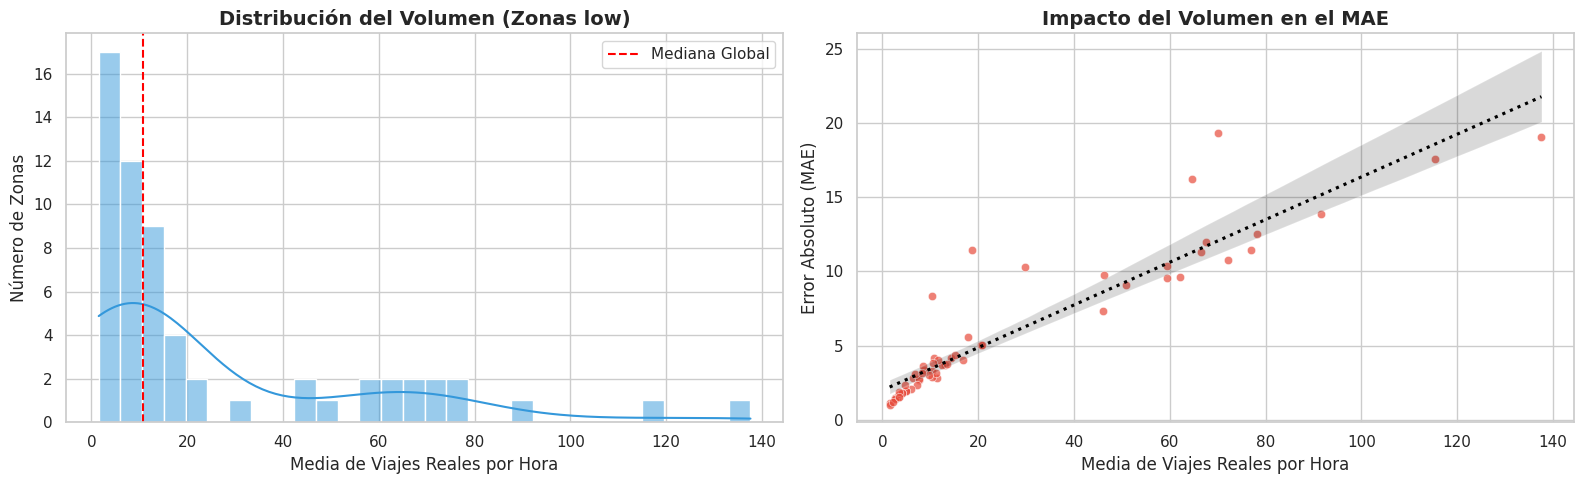


📋 Resumen Estadístico de las Zonas low:
       Demanda_Media    MAE  Error_Porcentual_%
count          61.00  61.00               61.00
mean           25.83   5.71               33.98
std            31.20   4.84               14.51
min             1.53   1.04               13.82
25%             4.99   2.06               24.19
50%            10.70   3.67               32.07
75%            45.97   9.57               43.10
max           137.59  19.30               79.80


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from darts.metrics import mae

print("⏳ Recopilando datos y errores EXACTOS del modelo LOW...")

# 1. Sacamos las predicciones del modelo low
preds_tf_hist_base = modelo_low.historical_forecasts(
    series=val_low["targets"],
    past_covariates=val_low["past"],
    future_covariates=train_low["future"],
    start=72,                   
    forecast_horizon=24,        
    stride=24,                  
    retrain=False,              
    last_points_only=False,     
    num_samples=200             
)

# 2. Invertimos la realidad y calculamos los errores zona por zona
val_real_base = val_low["targets_real"]
errores_zona_base = []
demanda_media_zonas = []

for i, lista_dias_zona in enumerate(preds_tf_hist_base):
    # Calcular MAE
    errores_dias = []
    for dia_pred_tf in lista_dias_zona:
        dia_pred_real = pipe_low.inverse_transform(dia_pred_tf)
        pred_p50 = dia_pred_real.quantile(0.50)
        actual_real = val_real_base[i].slice_intersect(pred_p50)
        errores_dias.append(mae(actual_real, pred_p50))
    
    mae_zona_total = np.mean(errores_dias)
    errores_zona_base.append(mae_zona_total)
    
    # Calcular volumen medio de la zona (usando la realidad invertida)
    media_viajes = val_real_base[i].values().flatten().mean()
    demanda_media_zonas.append(media_viajes)

# 3. Construimos el DataFrame para el análisis
df_analisis_base = pd.DataFrame({
    'Demanda_Media': demanda_media_zonas,
    'MAE': errores_zona_base
})

# Añadimos un pequeño epsilon (0.1) para evitar divisiones por cero
df_analisis_base['Error_Porcentual_%'] = (df_analisis_base['MAE'] / (df_analisis_base['Demanda_Media'] + 0.1)) * 100

# ==========================================
# VISUALIZACIÓN
# ==========================================
print("📊 Generando gráficos...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- GRÁFICO 1: Distribución de la Demanda ---
sns.histplot(data=df_analisis_base, x='Demanda_Media', bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Distribución del Volumen (Zonas low)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Media de Viajes Reales por Hora')
axes[0].set_ylabel('Número de Zonas')
axes[0].axvline(df_analisis_base['Demanda_Media'].median(), color='red', linestyle='--', label='Mediana Global')
axes[0].legend()

# --- GRÁFICO 2: ¿Afecta el volumen al MAE? ---
sns.scatterplot(data=df_analisis_base, x='Demanda_Media', y='MAE', alpha=0.7, color='#e74c3c', ax=axes[1])
sns.regplot(data=df_analisis_base, x='Demanda_Media', y='MAE', scatter=False, color='black', line_kws={'linestyle':':'}, ax=axes[1])

axes[1].set_title('Impacto del Volumen en el MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Media de Viajes Reales por Hora')
axes[1].set_ylabel('Error Absoluto (MAE)')

plt.tight_layout()
plt.show()

# ==========================================
# RESUMEN ESTADÍSTICO
# ==========================================
print("\n📋 Resumen Estadístico de las Zonas low:")
print(df_analisis_base[['Demanda_Media', 'MAE', 'Error_Porcentual_%']].describe().round(2))

veamos tb que tal iria simplemente predecir la anterior hora

In [53]:
import pandas as pd
import numpy as np

print("⏳ Evaluando Modelo Heurístico (Media 2h) para el segmento BASELINE...")

# 1. Definimos la ventana de tiempo (Igual que en TiDE para que sea comparable)
DIAS_VAL = 24
HORAS_HISTORIA = 2

fecha_max = df_baseline['timestamp'].max()
inicio_val = fecha_max - pd.Timedelta(days=DIAS_VAL)
inicio_historia = inicio_val - pd.Timedelta(hours=HORAS_HISTORIA)

# 2. Recortamos el dataset para no usar RAM innecesaria
df_eval = df_baseline[df_baseline['timestamp'] >= inicio_historia].copy()

# 3. RECONSTRUCCIÓN DE CEROS (El truco maestro)
# Como la zona BASELINE tiene horas desaparecidas, creamos un grid de tiempo perfecto
rango_horas = pd.date_range(start=inicio_historia, end=fecha_max, freq='h')
series_unicas = df_eval['Series_ID'].unique()

# Creamos un índice con todas las combinaciones posibles de Zona + Hora
idx_perfecto = pd.MultiIndex.from_product([series_unicas, rango_horas], names=['Series_ID', 'timestamp'])

# Reindexamos: si a una zona le falta una hora, Pandas pone un 0 en la demanda automáticamente
df_completo = df_eval.set_index(['Series_ID', 'timestamp'])[['demand']].reindex(idx_perfecto, fill_value=0).reset_index()

# 4. Cálculo de la Media Móvil (Heurística)
# Usamos shift(1) para evitar Data Leakage: La predicción de las 08:00 usa la media de 07:00 hacia atrás.
df_completo['pred_72h'] = df_completo.groupby('Series_ID')['demand'].transform(
    lambda x: x.shift(1).rolling(window=HORAS_HISTORIA, min_periods=1).mean()
)

# 5. Evaluación (Solo evaluamos los 14 días de validación reales, ignoramos los 3 de calentamiento)
df_val_final = df_completo[df_completo['timestamp'] > inicio_val].dropna()

# Calculamos MAE Global y por Zona
mae_global = np.abs(df_val_final['demand'] - df_val_final['pred_72h']).mean()

# Agrupamos para ver cuáles son las zonas con más error dentro del Baseline
mae_por_zona = df_val_final.groupby('Series_ID').apply(
    lambda x: np.abs(x['demand'] - x['pred_72h']).mean()
).sort_values(ascending=False)

print("\n" + "="*60)
print(f"🎯 RESULTADOS BASELINE (Media Móvil 72h sobre {len(series_unicas)} zonas):")
print(f"   - MAE Global del segmento: {mae_global:.3f} viajes/hora")
print("="*60)

print("\nTop 5 zonas con mayor error en el Baseline (Posibles candidatas a revisar):")
print(mae_por_zona.head(5))

⏳ Evaluando Modelo Heurístico (Media 2h) para el segmento BASELINE...

🎯 RESULTADOS BASELINE (Media Móvil 72h sobre 425 zonas):
   - MAE Global del segmento: 0.550 viajes/hora

Top 5 zonas con mayor error en el Baseline (Posibles candidatas a revisar):
Series_ID
0_255    5.700521
0_112    4.053819
0_80     3.962674
0_37     3.602431
0_76     3.314236
dtype: float64
